# 1. Título y equipo
# Predicción de Ventas - Eleven Pro

**Objetivo del proyecto:**
Construir un modelo predictivo que estime las ventas globales futuras de la tienda y generar recomendaciones para la gestión de inventario.

**Equipo de trabajo:**
1. Eduardo José Padilla Jaramillo
2. Gustavo Adolfo Gordillo Millán
3. José Eduardo Borja
4. Lina Marcela Zambrano Ramírez

**Fecha:**
Abril 07 de 2026

**Enlace GitHub:**
(https://github.com/INTEP-Analitica-2026/Prediccion-Ventas-Elevenpro.git)

**Estructura del notebook:**
1. Carga y exploración de datos
2. Análisis de correlación
3. Regresión Lineal Simple
4. Regresión Lineal Múltiple
5. Comparación de modelos y métricas
6. Diagnóstico de residuos
7. Selección y justificación del mejor modelo
8. Interpretación de negocio

# 2. Problema del negocio
Una tienda de venta de Ropa deportiva llamada Eleven Pro necesita anticipar cuánto venderá en las próximas semanas para gestionar inventario, personal y presupuesto. Actualmente las decisiones se toman por intuición o con promedios simples, lo que genera sobrestock o desabastecimiento y posibles incumplimientos con las entregas.

# 3. Carga y descripción de datos

**Datasets utilizados:**
| # | Archivo | Granularidad | Registros | Variables |
|---|---|---|---|---|
| 1 | `01_ordenes_limpias.csv` | Por línea de producto por orden | 1,236 | 22 |
| 2 | `02_ventas_diarias.csv` | Diaria (solo días con ventas) | 423 | 16 |
| 3 | `03_ventas_semanales.csv` | Semanal | 115 | 4 |
| 4 | `04_productos.csv` | Por variante de producto (SKU) | 2,701 | 8 |
| 5 | `06_ventas_mensuales_completas.csv` | Mensual | 29 | 16 |
| 6 | `07_ventas_diarias_completas_shopify.csv` | Diaria (todos los días) | 782 | 21 |

**Variable objetivo principal (Y):** `ventas_totales` diarias (COP)

# 3.1. `01_ordenes_limpias.csv` (22 variables)

> Registros: 1,236 | Período: Oct 2023 → Feb 2026 | Granularidad: **UNA FILA = UN ÍTEM EN UNA ORDEN**

| Variable | Tipo | Categoría | Descripción | Rango / Valores | Nulos | Uso en modelo |
|---|---|---|---|---|---|---|
| `pedido` | int64 | 🔑 Identificación | Número único de orden de compra. Varias filas pueden compartir el mismo pedido si el cliente compró múltiples productos. | 1001 – 3117 | 0 | No (identificador) |
| `fecha_pedido` | str (datetime con zona horaria) | 📅 Temporal | Fecha y hora exacta en que se realizó el pedido, incluyendo zona horaria UTC-5 (hora de Colombia). Contiene marca de tiempo completa (año, mes, día, hora, minuto, segundo). | 2023-10-10 → 2026-02-19 | 0 | No (se usa la columna fecha procesada) |
| `fecha` | datetime64 | 📅 Temporal | Fecha de la orden en formato DD/MM/AAAA, sin hora. Versión simplificada de fecha_pedido para agrupar por día. Parseada a datetime en el preprocesamiento. | 10/10/2023 – 19/02/2026 | 0 | Sí (base para features temporales: mes, dia_semana, anio) |
| `financial_status` | str | 💳 Estado de pago | Estado financiero de la orden en Shopify. En este dataset todos los registros tienen valor "paid" (pagado), lo que indica que el dataset ya fue filtrado para incluir solo órdenes completadas y cobradas. No hay órdenes pendientes, canceladas o reembolsadas. | paid (100% de los casos) | 0 | No (sin varianza) |
| `total` | float64 | 💰 Financiero | Valor total de la orden completa en pesos colombianos (COP), incluyendo todos los ítems + envío + impuestos - descuentos. Este es el dinero que efectivamente pagó el cliente por el pedido entero. Nota: varias filas del mismo pedido repiten este valor. | $94,900 – $1,079,400 COP | 0 | Indirectamente (ventas_totales en datasets diarios) |
| `subtotal` | float64 | 💰 Financiero | Valor de los productos de la orden antes de sumar envío e impuestos, pero después de aplicar descuentos sobre los ítems. Representa el valor neto de los productos vendidos. | $79,900 – $1,079,400 COP | 0 | No directamente |
| `shipping` | float64 | 🚚 Logístico | Costo de envío cobrado al cliente en COP. Valor de 0 indica envío gratis (que es la política más común en Eleven Pro, usada como incentivo comercial). Cuando hay costo, oscila entre $5,000 y $15,000. | $0 – $15,000 COP \| Media: $4,235 | 0 | No |
| `taxes` | float64 | 💰 Financiero | Impuestos aplicados a la orden en COP. En Colombia, los artículos de ropa deportiva pueden estar gravados con IVA (19%) según el tipo de producto. Muchos pedidos tienen taxes = 0, posiblemente porque el precio ya incluye impuestos o aplica exención. | $0 – $142,787 COP \| Media: $18,779 | 0 | No |
| `discount_code` | str | 🏷️ Descuentos | Código de cupón de descuento utilizado en la orden. NaN indica que no se aplicó ningún cupón. Los códigos más frecuentes son "ELEVENPRO10" (10% de descuento) y variantes. Solo 1 registro tiene este campo nulo pero sí tiene discount_amount > 0. | ELEVENPRO10, #LUCYELEVEN, LUCY11, etc. | 1 | No (se usa discount_amount numéricamente) |
| `discount_amount` | float64 | 🏷️ Descuentos | Monto total del descuento aplicado a la orden completa en COP. Es el valor en dinero que se restó del precio original. Valor 0 significa que no hubo descuento. Suma de todos los descuentos (cupón + descuento por ítem) de la orden. | $0 – $469,800 COP \| Media: $18,099 | 0 | Sí (como feature "descuentos" en datasets diarios) |
| `sku` | int64 | 📦 Producto | Stock Keeping Unit — código numérico único que identifica una variante específica de producto (combinación de modelo + talla + color + manga). Permite vincular este dataset con el catálogo 04_productos.csv. El valor 99999 es un código temporal o de prueba. | 1201 – 81,505,728 (numérico, no ordinal) | 0 | No directamente (se usa categoria_producto) |
| `producto` | str | 📦 Producto | Nombre descriptivo completo de la variante del producto vendido. Incluye nombre del modelo, talla, color y tipo de manga. Ejemplo: "Camiseta Tour de Francia azul hombre - M / Manga corta". Permite identificar exactamente qué se vendió. | 892 variantes únicas \| Top: Camiseta Tour de Francia azul hombre - M | 0 | No (texto libre, se usa categoria_producto) |
| `cantidad` | int64 | 📦 Producto | Número de unidades del mismo ítem compradas en esa línea de la orden. La gran mayoría de las líneas tienen cantidad = 1 (97.2%). Rara vez un cliente compra 2 o más unidades del mismo producto. NOTA: Esta fue la variable objetivo original del notebook, pero se descartó por su varianza casi nula. | 1 (97.2%) \| 2 (2.3%) \| 3 (0.4%) \| 4 (0.08%) | 0 | Descartada como Y (varianza nula). Suma = unidades vendidas por día. |
| `precio_unitario` | float64 | 💰 Financiero | Precio de venta de una unidad del producto en COP, antes de aplicar descuentos a nivel de ítem. Es el precio de lista del producto. Permite calcular el ticket promedio y analizar elasticidad de precios. | $24,000 – $403,900 COP \| Media: $171,407 | 0 | No directamente |
| `ImportadoIA` | str | 🤖 Metadato | Indicador de si el registro fue creado o enriquecido mediante inteligencia artificial. "SI" = el campo fue completado/inferido por IA (21.3% de registros). "NO" = dato original directo de Shopify. Útil para auditoría de calidad de datos. | NO (78.7%) \| SI (21.3%) | 0 | No |
| `descuento_item` | float64 | 🏷️ Descuentos | Descuento aplicado específicamente a ese ítem individual en COP, a diferencia de discount_amount que es el descuento total de la orden. La mayoría de las líneas tienen valor 0. Se usa para distinguir descuentos por producto vs descuentos globales de la orden. | $0 – $239,900 COP \| Media: $5,025 | 0 | No |
| `categoria_producto` | str | 📦 Producto | Agrupación del producto en una categoría comercial de la tienda. Permite analizar qué tipo de ropa deportiva se vende más. Jersey y Jerseys son la misma categoría con nombre inconsistente (dato de calidad a corregir). | Jersey (29%), Pantalonetas (22%), Camisetas (21%), Jerseys (11%), Enterizo (6%), Calcetines (4%), otros | 0 | Potencial feature para modelos por categoría |
| `canal` | str | 📡 Canal de venta | Canal a través del cual se realizó la compra. "web" = tienda online Shopify (98.2%). "draft_order" = pedido creado manualmente por el equipo de ventas (pedidos por WhatsApp/telefónico). "otro_canal" = canal no identificado. | web (98.2%) \| draft_order (1.5%) \| otro_canal (0.2%) | 0 | No (sin varianza práctica) |
| `ciudad` | str | 🗺️ Geográfico | Ciudad de destino del envío del pedido, correspondiente a la dirección de entrega del cliente. "Sin información" indica que el cliente no registró dirección o usó facturación sin envío. Permite analizar la penetración geográfica de la marca. | 154 ciudades únicas \| Top: Sin información (28%), Bogotá D.C., Medellín, Cali | 0 | No (alta cardinalidad, 154 categorías) |
| `departamento` | str | 🗺️ Geográfico | Departamento colombiano de destino del pedido. Permite análisis regional de ventas. La alta proporción de "Sin información" sugiere pedidos digitales sin dirección física o datos incompletos en Shopify. | 30 departamentos \| Top: Sin información (28%), Bogotá D.C. (12%), Cundinamarca (8%), Valle del Cauca (7%), Antioquia (7%) | 0 | No |
| `payment_method` | str | 💳 Pago | Pasarela o método de pago utilizado. Addi Payment es una financiera colombiana que permite compras a cuotas sin interés, muy popular en Colombia. Wompi y ePayco son pasarelas de pago. Puede haber métodos combinados cuando el cliente dividió el pago. | Addi Payment (70.2%) \| Wompi (14.9%) \| ePayco (7.5%) \| Combinados (7.4%) | 0 | No directamente. Insight: Addi facilita compras de alto valor. |
| `risk_level` | str | ⚠️ Riesgo | Nivel de riesgo de fraude asignado por Shopify al pedido mediante su sistema de análisis antifraude. "Low" = bajo riesgo (98.5%). "Medium" = riesgo medio (1.5%). No hay pedidos de alto riesgo, lo que indica una base de clientes confiable. | Low (98.5%) \| Medium (1.5%) | 0 | No (sin varianza práctica) |


# 3.2. `02_ventas_diarias.csv` (16 variables)

> Registros: 423 | Solo días **CON ventas** | Oct 2023 → Feb 2026

| Variable | Tipo | Categoría | Descripción | Rango / Valores | Nulos |
|---|---|---|---|---|---|
| `fecha` | str → datetime | 📅 Temporal | Fecha del día en formato AAAA-MM-DD. Solo aparecen días que tuvieron al menos una orden pagada. Parsear a datetime antes de usar. | 2023-10-10 → 2026-02-19 | 0 |
| `ventas_totales` | float64 | 💰 KPI Principal | Suma de los valores totales de todas las órdenes del día en COP. Es la variable objetivo más importante para el negocio. Incluye productos + envío + impuestos - descuentos. | $104,900 – $3,193,850 COP \| Media: $501,922 | 0 |
| `num_ordenes` | int64 | 📊 KPI Operacional | Número total de pedidos distintos procesados en el día. Un pedido puede contener varios ítems. Es el KPI más correlacionado con ventas (r=0.87 en este dataset). | 1 – 19 órdenes/día \| Media: 2.1 | 0 |
| `ticket_promedio` | float64 | 💰 KPI Financiero | Valor promedio por orden del día, calculado como ventas_totales / num_ordenes. Indica el gasto promedio por compra. Útil para segmentar días de compras grandes vs. múltiples compras pequeñas. | $104,900 – $869,700 COP \| Media: $257,220 | 0 |
| `descuento_total` | float64 | 🏷️ Descuentos | Suma total de los descuentos aplicados en todas las órdenes del día en COP. Permite medir el impacto económico de las campañas de descuento diarias. | $0 – $1,169,500 COP \| Media: $24,069 | 0 |
| `pedidos_con_descuento` | int64 | 🏷️ Descuentos | Número de pedidos del día que utilizaron algún cupón o descuento. Permite calcular la tasa de adopción de descuentos por día. | 0 – 4 pedidos \| Media: 0.28 | 0 |
| `dia_semana` | int64 | 📅 Temporal | Número del día dentro de la semana según Python/pandas. 0 = Lunes, 1 = Martes, ..., 6 = Domingo. Permite analizar patrones de compra según el día de la semana. | 0 (Lun) – 6 (Dom) | 0 |
| `nombre_dia` | str | 📅 Temporal | Nombre del día de la semana en inglés correspondiente a dia_semana. Es la representación legible de la variable dia_semana. Valores: Monday, Tuesday, Wednesday, Thursday, Friday, Saturday, Sunday. | Monday – Sunday | 0 |
| `mes` | int64 | 📅 Temporal | Número del mes del año (1=Enero, 12=Diciembre). Permite identificar estacionalidad mensual. Los meses con mayor actividad son junio y agosto (eventos ciclísticos como Tour de Francia). | 1 – 12 | 0 |
| `anio` | int64 | 📅 Temporal | Año del registro. Permite analizar tendencias interanuales de crecimiento. | 2023, 2024, 2025, 2026 | 0 |
| `dia_mes` | int64 | 📅 Temporal | Día del mes (1 a 31). Permite detectar patrones quincenales o de inicio/fin de mes (ej. compras al recibir salario). | 1 – 31 | 0 |
| `semana_anio` | int64 | 📅 Temporal | Número de la semana ISO del año (1-52). Permite granularidad entre mes y día. Útil para alinear con eventos ciclísticos que duran semanas. | 1 – 52 | 0 |
| `es_fin_semana` | int64 (binaria) | 📅 Temporal | Indicador binario: 1 si el día es sábado o domingo, 0 si es día hábil (lunes a viernes). En Eleven Pro los fines de semana suelen tener menor volumen de pedidos. | 0 = Lunes-Viernes (72.8%) \| 1 = Sáb-Dom (27.2%) | 0 |
| `trimestre` | int64 | 📅 Temporal | Trimestre del año: Q1=1 (Ene-Mar), Q2=2 (Abr-Jun), Q3=3 (Jul-Sep), Q4=4 (Oct-Dic). El Q2 concentra el mayor volumen de ventas debido al Tour de Francia (julio) y otros eventos. | Q1(21%) \| Q2(31%) \| Q3(27%) \| Q4(22%) | 0 |
| `ventas_dia_anterior` | float64 | ⏮️ Lag / Serie de tiempo | Ventas totales del día inmediatamente anterior (lag-1). Captura la inercia de ventas: un día con altas ventas tiende a ser seguido de otro con ventas similares. Es un predictor importante para modelos de series de tiempo. | $104,900 – $3,193,850 COP \| 1 nulo (primer registro) | 1 |
| `ventas_promedio_7d` | float64 | ⏮️ Lag / Serie de tiempo | Media móvil de las ventas de los últimos 7 días calendario. Suaviza la variabilidad diaria y captura la tendencia de corto plazo. Es un indicador del "ritmo" reciente de la tienda. | $180,117 – $1,574,435 COP \| Media: $501,557 | 0 |



# 3.3. `03_ventas_semanales.csv` (4 variables)

> Registros: 115 semanas | Período: Oct 2023 → Feb 2026

| Variable | Tipo | Descripción | Rango / Valores |
|---|---|---|---|
| `semana` | str → datetime | Fecha del primer día (lunes) de la semana en formato AAAA-MM-DD. Representa la semana ISO que comienza ese lunes. | 2023-10-09 → 2026-02-16 \| 115 semanas |
| `ventas_totales` | float64 | Suma de ventas de todos los días de esa semana en COP. Agrega los 7 días de la semana (o los días disponibles si es la primera/última semana del período). | $150,000 – $9,534,720 COP \| Media: $1,846,200 \| Std: $1,819,834 |
| `num_ordenes` | int64 | Total de pedidos procesados durante la semana. Permite ver el ritmo de demanda semanal y detectar semanas atípicas (promociones, lanzamientos). | 1 – 51 órdenes/semana \| Media: 7.7 |
| `ticket_promedio` | float64 | Promedio del valor por orden durante la semana (ventas_totales / num_ordenes). Semanas con pocos pedidos de alto valor pueden indicar compras corporativas o kits completos. | $139,900 – $652,275 COP \| Media: $265,543 |

# 3.4. `04_productos.csv` (8 variables)

> Registros: 2,701 variantes de producto

| Variable | Tipo | Descripción | Rango / Valores |
|---|---|---|---|
| `consecutivo` | int64 | Número de fila correlativo, del 1 al 2,701. Funciona como índice del catálogo. No tiene significado de negocio, es un identificador de posición. | 1 – 2,701 \| Nulos: 0 |
| `SKU` | float64 | Código numérico único (Stock Keeping Unit) que identifica cada variante de producto. Permite unir este catálogo con el campo "sku" del dataset maestro de órdenes. Tiene 577 nulos (21%), correspondientes a variantes sin código asignado aún en Shopify. | 1,100 – 81,505,728 \| Nulos: 577 (21.4%) |
| `Descripcion` | str | Nombre del modelo/diseño del producto en formato slug (palabras separadas por guiones, sin mayúsculas). Ejemplo: "jersey-aurora-eclipse-slim-fit". Un mismo modelo puede tener múltiples filas por sus variantes de talla y género. | ~120 modelos únicos \| Ej: jersey-aurora-eclipse-slim-fit, pantaloneta-estelar |
| `Talla` | str | Talla del producto según la tabla de tallas de Eleven Pro. XS es la talla más pequeña y 4XL la más grande. ST podría ser una talla estándar o especial. Las tallas S, M, L y XL son las más comunes en el catálogo. | XS, S, M, L, XL, 2XL, 3XL, 4XL, ST, 2XS \| M(24.3%), S(23.5%), L(22.1%) |
| `Genero_Uso` | str | Género o uso al que está destinado el producto. "Unisex" domina el catálogo (77.6%) porque jerseys y pantalonetas suelen diseñarse para uso mixto. Masculino y Femenino indican cortes específicos de género. | Unisex (77.6%) \| Masculino (12.1%) \| Femenino (10.4%) |
| `Longitud_Manga` | str | Tipo de manga del producto. "Sin Dato" aplica a prendas que no tienen manga (pantalonetas, calcetines, enterisos sin manga). "Manga Corta" y "Manga Larga" para camisetas y jerseys. "Manga Siza" es manga sin costura. | Sin Dato (72.2%) \| Manga Corta (18.4%) \| Manga Larga (9.3%) \| Manga Siza (0.1%) |
| `Precio` | float64 | Precio de venta al público (PVP) del producto en COP. Es el precio de lista antes de cualquier descuento. Los 57 nulos corresponden a variantes sin precio asignado (productos en preparación o descontinuados). | $0 – $496,200 COP \| Media: $233,592 \| Nulos: 57 |
| `Color` | str | Color de la variante del producto. La alta proporción de nulos (63.7%) indica que muchos productos no tienen color diferenciador registrado en el catálogo, posiblemente porque el color está implícito en el nombre del modelo. | Azul, Red, Black, White, etc. \| Nulos: 1,720 (63.7%) |

# 3.5. `06_ventas_mensuales_completas.csv` (16 variables)

> Registros: 29 meses | Oct 2023 → Feb 2026

| Variable | Categoría | Descripción | Rango / Valores |
|---|---|---|---|
| `fecha` | 📅 Temporal | Primer día del mes en formato AAAA-MM-DD. Identifica el mes de reporte. | 2023-10-01 → 2026-02-01 \| 29 meses |
| `pedidos` | 📊 KPI Operacional | Total de órdenes del mes. Incluye todos los pedidos pagados. Alta variabilidad: de 9 pedidos en meses lentos hasta 523 en junio 2024 (lanzamiento masivo con campaña Tour de Francia). | 9 – 523 \| Media: 73 \| Nulos: 0 |
| `ventas_brutas` | 💰 Financiero | Valor total de los productos vendidos al precio de lista, ANTES de restar descuentos y devoluciones. Es el indicador de demanda bruta del mes. | $2.4M – $75.4M COP \| Media: $14.3M |
| `descuentos` | 🏷️ Descuentos | Total de descuentos otorgados en el mes en COP (cupones, promociones, rebajas). Se resta de ventas_brutas para obtener ventas_netas. | $0 – $5,433,680 COP \| Media: $439,118 |
| `devoluciones` | 🔄 Devoluciones | Total de devoluciones del mes en COP. Dinero devuelto a clientes por productos retornados o cancelaciones. Puede ser 0 en meses sin incidencias. | $0 – $7,929,920 COP \| Media: $1,354,735 |
| `ventas_netas` | 💰 Financiero | Ventas después de descontar descuentos y devoluciones: ventas_brutas - descuentos - devoluciones. Representa el ingreso real por productos en el mes. | $1.5M – $70.1M COP \| Media: $12.5M |
| `envio` | 🚚 Logístico | Ingresos netos por envío en el mes. Puede ser negativo si las devoluciones incluyen reembolso de envío. La presencia de valores negativos indica meses con muchas devoluciones de pedidos con envío. | -$45,000 – $5,715,000 COP \| Media: $529,137 |
| `impuestos` | 💰 Financiero | Impuestos cobrados a los clientes en el mes (IVA y otros). Valor 0 en algunos meses indica que los precios ya incluyen IVA o que aplica régimen simplificado. | $0 – $6,196,649 COP \| Media: $733,222 |
| `ventas_totales` | 💰 KPI Principal | Ingresos totales del mes incluyendo todo: ventas_netas + envío + impuestos. Es el dinero total que entró a la caja de Eleven Pro en el mes. | $1.76M – $82.02M COP \| Media: $13.74M |
| `anio` | 📅 Temporal | Año del mes reportado. | 2023 – 2026 |
| `mes` | 📅 Temporal | Número del mes (1-12). | 1 – 12 |
| `nombre_mes` | 📅 Temporal | Nombre del mes en inglés, correspondiente a la variable "mes". | January – December |
| `trimestre` | 📅 Temporal | Trimestre del año: 1=Q1 (Ene-Mar), 2=Q2 (Abr-Jun), 3=Q3 (Jul-Sep), 4=Q4 (Oct-Dic). | 1 – 4 |
| `tasa_devolucion` | 🔄 Devoluciones | Porcentaje de ventas brutas que fue devuelto: (devoluciones / ventas_brutas) × 100. Mide la eficiencia operacional. Una tasa alta puede indicar problemas de calidad o tallas. Valor máximo de 61% en un mes fue atípico. | 0% – 61.01% \| Media: 10.64% |
| `ventas_mes_anterior` | ⏮️ Lag | Ventas totales del mes inmediatamente anterior (lag-1 mensual). Permite calcular la variación y modelar con autocorrelación temporal. NaN en el primer mes del registro. | $1.76M – $82.02M COP \| Nulos: 1 |
| `variacion_pct` | 📈 KPI de Crecimiento | Variación porcentual de ventas respecto al mes anterior: (ventas_totales - ventas_mes_anterior) / ventas_mes_anterior × 100. Valores extremos reflejan la alta estacionalidad del negocio (ej. +477% en abril 2024 vs marzo 2024). | -97.85% – +477.60% \| Media: +48.83% \| Nulos: 1 |

# 3.6. `07_ventas_diarias_completas_shopify.csv` ⭐ (21 variables)
### ⭐ Dataset principal del modelo de Machine Learning

**¿Por qué es el dataset principal del modelo?**
- ✅ Serie temporal **completa y continua** (sin espacios o brechas)
- ✅ Incluye variables **lag (retraso) ** y **medias móviles (conjunto de ventas en un periodo)** ya calculadas
- ✅ Desglose financiero completo (brutas, netas, descuentos, devoluciones)
- ✅ 782 registros correspondientes a las ventas diarias.

> Registros: 782 días | Ene 2024 → Feb 2026 | **SERIE CONTINUA** (todos los días presento información de ventas)

| Variable | Categoría | Descripción | Rango / Valores |
|---|---|---|---|
| `fecha` | 📅 Temporal | Fecha del día en formato AAAA-MM-DD. TODOS los días están presentes, incluyendo días sin ventas (290 días con ventas = 0). Esto hace la serie continua. | 2024-01-01 → 2026-02-20 \| 782 días \| Nulos: 0 |
| `pedidos` | 📊 KPI Principal — Feature #1 | Número total de órdenes del día. Es la variable predictora MÁS IMPORTANTE del modelo (importancia del 91.8% en Gradient Boosting). Días sin pedidos tienen valor 0. | 0 – 54 pedidos/día \| Media: 2.63 \| Nulos: 0 |
| `ventas_brutas` | 💰 Financiero | Suma de los precios de lista de todos los productos vendidos en el día, antes de descuentos y devoluciones. El máximo de $7.3M COP en un día corresponde a jornadas de venta masiva. | $0 – $7,335,502 COP \| Media: $494,895 \| Nulos: 0 |
| `descuentos` | 🏷️ Descuentos — Feature | Descuentos totales aplicados en el día en COP. Se usa como feature en el modelo porque los días con descuentos tienen un patrón de ventas diferente (campañas promocionales). | $0 – $460,000 COP \| Media: $7,579 \| Nulos: 0 |
| `devoluciones` | 🔄 Devoluciones — Feature | Valor de devoluciones procesadas en el día en COP. Días con devoluciones altas pueden afectar las ventas netas negativamente. En el modelo tiene importancia del 2.1%. | $0 – $4,246,700 COP \| Media: $50,332 \| Nulos: 0 |
| `ventas_netas` | 💰 Financiero | ventas_brutas - descuentos - devoluciones. El valor puede ser negativo en días con muchas devoluciones sin nuevas ventas (mínimo: -$1,103,720 COP). | -$1,103,720 – $6,829,852 COP \| Media: $437,076 \| Nulos: 0 |
| `envio` | 🚚 Logístico | Cargo de envío neto del día. Negativo cuando hay reembolsos de envío por devoluciones mayores que los cargos nuevos. | -$90,000 – $675,000 COP \| Media: $19,680 \| Nulos: 0 |
| `impuestos` | 💰 Financiero | Impuestos del día. Puede ser negativo por notas de crédito o ajustes. Refleja el tratamiento fiscal de los productos. | -$42,279 – $660,498 COP \| Media: $27,073 \| Nulos: 0 |
| `ventas_totales` | 🎯 Variable Objetivo (Y) | **VARIABLE OBJETIVO DEL MODELO.** Ingresos totales del día: ventas_netas + envío + impuestos. Incluye días con valor 0 (sin ventas) y puede ser negativo (devoluciones masivas). El modelo predice este valor. | -$1,111,320 – $8,165,350 COP \| Media: $483,829 \| Nulos: 0 |
| `dia_semana` | 📅 Temporal — Feature | Día de la semana numérico (0=Lunes, 6=Domingo). Captura patrones semanales de compra. | 0 – 6 \| Nulos: 0 |
| `nombre_dia` | 📅 Temporal | Nombre del día en inglés. Versión legible de dia_semana. | Monday – Sunday \| Nulos: 0 |
| `mes` | 📅 Temporal — Feature | Mes del año (1-12). Captura estacionalidad mensual (picos en junio y agosto). | 1 – 12 \| Nulos: 0 |
| `anio` | 📅 Temporal — Feature | Año del registro. Captura tendencia interanual de crecimiento del negocio. | 2024 – 2026 \| Nulos: 0 |
| `dia_mes` | 📅 Temporal — Feature | Día dentro del mes (1-31). Captura patrones quincenales, como compras al inicio de mes (pago de salario). | 1 – 31 \| Nulos: 0 |
| `semana_anio` | 📅 Temporal — Feature | Semana ISO del año (1-52). Permite granularidad entre mes y día para alinear con eventos deportivos. | 1 – 52 \| Nulos: 0 |
| `es_fin_semana` | 📅 Temporal — Feature | Indicador binario: 1 = sábado o domingo, 0 = día hábil. Los fines de semana tienen un patrón de compra diferente en ecommerce. | 0 (72%) \| 1 (28%) \| Nulos: 0 |
| `trimestre` | 📅 Temporal — Feature | Trimestre fiscal del año: 1=Q1, 2=Q2, 3=Q3, 4=Q4. | 1 – 4 \| Nulos: 0 |
| `ventas_dia_anterior` | ⏮️ Lag-1 — Feature | Ventas totales del día anterior (lag de 1 día). Captura la autocorrelación de corto plazo. Importancia en modelo: 1.3%. Puede ser negativo si el día anterior tuvo devoluciones netas. | -$1,111,320 – $8,165,350 COP \| Nulos: 0 (relleno con 0) |
| `ventas_promedio_7d` | 📊 Media Móvil — Feature | Media aritmética de las ventas de los últimos 7 días. Suaviza la variabilidad diaria y captura la tendencia de la semana reciente. Importancia en modelo: 0.9%. | -$158,760 – $5,330,053 COP \| Media: $478,766 \| Nulos: 0 |
| `ventas_promedio_30d` | 📊 Media Móvil — Feature | Media de ventas de los últimos 30 días. Captura la tendencia del mes reciente, más estable que la de 7 días. Útil para detectar cambios de régimen en el nivel de ventas. | $35,415 – $2,747,974 COP \| Media: $467,547 \| Nulos: 0 |
| `pedidos_promedio_7d` | 📊 Media Móvil — Feature | Media de pedidos de los últimos 7 días. Análogo a ventas_promedio_7d pero en número de órdenes. Captura el ritmo reciente de demanda en unidades. | 0 – 34.43 pedidos/día \| Media: 2.59 \| Nulos: 0 |

**Relaciones entre datasets:**
- `01_ordenes` → agrega por día → `02_ventas_diarias`
- `02_ventas_diarias` → agrega por semana → `03_ventas_semanales`
- `02_ventas_diarias` → agrega por mes → `06_ventas_mensuales`
- `01_ordenes` → JOIN por SKU → `04_productos`
- `07_ventas_shopify` → fuente independiente Shopify con lags pre-calculados

**Jerarquía de granularidad:**
`04_productos` (variante) > `01_ordenes` (línea) > `02/07` (día) > `03` (semana) > `06` (mes)

In [1]:
# Librerías necesarias
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
import os
warnings.filterwarnings('ignore')

# Configuración visual
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")
sns.set_palette("husl")

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


In [2]:
# Cargue de Datasets

# Función para cargar archivos CSV con separadores y encodings mixtos

def load_csv(path, sep=',', encoding='utf-8'):
    try:
        return pd.read_csv(path, sep=sep, encoding=encoding, on_bad_lines='skip')
    except Exception:
        return pd.read_csv(path, sep=sep, encoding='latin1', on_bad_lines='skip')

# Función para limpiar numeros con formato de serpacion de miles y decimales
# Convierte formato de número español (1.234,56) a float (1234.56)

def limpiar_num(s):
    
    if pd.isna(s): return np.nan
    s = str(s).replace('.', '').replace(',', '.').strip()
    try: return float(s)
    except: return np.nan

# Cargue de los 6 Datasets
ordenes      = load_csv('./datos/01_ordenes_limpias.csv', sep=';', encoding='latin1')
vd           = load_csv('./datos/02_ventas_diarias.csv')
vs_sem       = load_csv('./datos/03_ventas_semanales.csv')
productos    = load_csv('./datos/04_productos.csv', sep=';', encoding='latin1')
vm           = load_csv('./datos/06_ventas_mensuales_completas.csv')
vs           = load_csv('./datos/07_ventas_diarias_completas_shopify.csv')

# Limpiar nombres de columnas
ordenes.columns = ordenes.columns.str.strip()

# Limpiar columnas numéricas en formato español del dataset ordenes
for col in ['total', 'subtotal', 'shipping', 'taxes', 'discount_amount', 'precio_unitario']:
    ordenes[col] = ordenes[col].apply(limpiar_num)

# Parseo de fechas y creacion de nuevas variables temporales en el dataset ordenes
ordenes['fecha'] = pd.to_datetime(ordenes['fecha'], dayfirst=True, errors='coerce')
# Extraemos características temporales para análisis y modelado
ordenes['mes']       = ordenes['fecha'].dt.month        # Extracción del mes (1-12)
ordenes['dia_semana']= ordenes['fecha'].dt.dayofweek    # Extracción del día de la semana (0=Lunes, 6=Domingo)
ordenes['anio']      = ordenes['fecha'].dt.year         # Extracción del año (2023)
ordenes['tiene_descuento'] = (ordenes['discount_amount'] > 0).astype(int) # Variable binaria (booleana) para indicar si la orden tiene descuento = (1) o no (0)
# Parseo de fecha en el dataset ventas mensuales
vm['fecha']    = pd.to_datetime(vm['fecha'])
# Parseo de fecha en el dataset ventas semanales
vs['fecha']    = pd.to_datetime(vs['fecha'])
# Parseo de fecha en el dataset ventas diarias
vd['fecha']    = pd.to_datetime(vd['fecha'])

# Para el dataset de ventas diarias de shopify se rellena los valores faltantes con 0 en caso de que existan
vs = vs.fillna(0)

print(f"01_ordenes_limpias    : {ordenes.shape[0]:,} filas × {ordenes.shape[1]} cols")
print(f"02_ventas_diarias     : {vd.shape[0]:,} filas × {vd.shape[1]} cols")
print(f"03_ventas_semanales   : {vs_sem.shape[0]:,} filas × {vs_sem.shape[1]} cols")
print(f"04_productos          : {productos.shape[0]:,} filas × {productos.shape[1]} cols")
print(f"06_ventas_mensuales   : {vm.shape[0]:,} filas × {vm.shape[1]} cols")
print(f"07_ventas_shopify     : {vs.shape[0]:,} filas × {vs.shape[1]} cols")
print(f"\nVariable objetivo: ventas_totales diarias (COP)")
print(f" Rango histórico: {vs['fecha'].min().date()} → {vs['fecha'].max().date()}")

01_ordenes_limpias    : 1,236 filas × 26 cols
02_ventas_diarias     : 423 filas × 16 cols
03_ventas_semanales   : 115 filas × 4 cols
04_productos          : 2,701 filas × 8 cols
06_ventas_mensuales   : 29 filas × 16 cols
07_ventas_shopify     : 782 filas × 21 cols

Variable objetivo: ventas_totales diarias (COP)
 Rango histórico: 2024-01-01 → 2026-02-20


# 4. EDA (Exploración)

In [3]:
# Vista general del dataset 07_ventas_shopify.csv
print("=" * 60)
print("Dataset: 07_ventas_shopify.csv")
print("=" * 60)
print(f"\nDimensiones: {vs.shape[0]:,} registros × {vs.shape[1]} variables")
print(f"\nVariables disponibles:")
for i, col in enumerate(vs.columns, 1):
    print(f"  {i:02d}. {col}  [{vs[col].dtype}]")
print(f"\n{'─'*60}")

Dataset: 07_ventas_shopify.csv

Dimensiones: 782 registros × 21 variables

Variables disponibles:
  01. fecha  [datetime64[ns]]
  02. pedidos  [int64]
  03. ventas_brutas  [float64]
  04. descuentos  [float64]
  05. devoluciones  [float64]
  06. ventas_netas  [float64]
  07. envio  [int64]
  08. impuestos  [float64]
  09. ventas_totales  [float64]
  10. dia_semana  [int64]
  11. nombre_dia  [object]
  12. mes  [int64]
  13. anio  [int64]
  14. dia_mes  [int64]
  15. semana_anio  [int64]
  16. es_fin_semana  [int64]
  17. trimestre  [int64]
  18. ventas_dia_anterior  [float64]
  19. ventas_promedio_7d  [float64]
  20. ventas_promedio_30d  [float64]
  21. pedidos_promedio_7d  [float64]

────────────────────────────────────────────────────────────


In [4]:
# Verficación de valores nulos

print(vs.isnull().sum())

fecha                  0
pedidos                0
ventas_brutas          0
descuentos             0
devoluciones           0
ventas_netas           0
envio                  0
impuestos              0
ventas_totales         0
dia_semana             0
nombre_dia             0
mes                    0
anio                   0
dia_mes                0
semana_anio            0
es_fin_semana          0
trimestre              0
ventas_dia_anterior    0
ventas_promedio_7d     0
ventas_promedio_30d    0
pedidos_promedio_7d    0
dtype: int64


In [5]:
# Estadistica descriptiva básica del dataset 07_ventas_shopify.csv
print("Estadísticas descriptivas (numéricas):")
display(vs.describe())

Estadísticas descriptivas (numéricas):


,fecha,pedidos,ventas_brutas,descuentos,devoluciones,ventas_netas,envio,impuestos,ventas_totales,dia_semana,mes,anio,dia_mes,semana_anio,es_fin_semana,trimestre,ventas_dia_anterior,ventas_promedio_7d,ventas_promedio_30d,pedidos_promedio_7d
count,782,782.000000,7.820000e+02,782.000000,7.820000e+02,7.820000e+02,782.000000,782.000000,7.820000e+02,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,7.820000e+02,7.820000e+02,7.820000e+02,782.000000
mean,2025-01-25 12:00:00,2.631714,4.948951e+05,7579.092238,5.033264e+04,4.370764e+05,19680.306905,27072.953184,4.838297e+05,2.993606,6.185422,2024.597187,15.615090,24.971867,0.283887,2.409207,4.839640e+05,4.787660e+05,4.675478e+05,2.593504
min,2024-01-01 00:00:00,0.000000,0.000000e+00,0.000000,0.000000e+00,-1.103720e+06,-90000.000000,-42278.990000,-1.111320e+06,0.000000,1.000000,2024.000000,1.000000,1.000000,0.000000,1.000000,-1.111320e+06,-1.587600e+05,3.541500e+04,0.000000
25%,2024-07-14 06:00:00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,1.000000,3.000000,2024.000000,8.000000,11.000000,0.000000,1.000000,0.000000e+00,1.218060e+05,1.430365e+05,0.570000
50%,2025-01-25 12:00:00,1.000000,2.392357e+05,0.000000,0.000000e+00,2.279400e+05,0.000000,0.000000,2.279400e+05,3.000000,6.000000,2025.000000,16.000000,25.000000,0.000000,2.000000,2.279400e+05,2.626435e+05,2.851120e+05,1.070000
75%,2025-08-08 18:00:00,3.000000,6.316172e+05,0.000000,0.000000e+00,5.798000e+05,15000.000000,21538.660000,6.110700e+05,5.000000,9.000000,2025.000000,23.000000,38.750000,1.000000,3.000000,6.110700e+05,5.154995e+05,5.373425e+05,2.570000
max,2026-02-20 00:00:00,54.000000,7.335502e+06,460000.000000,4.246700e+06,6.829852e+06,675000.000000,660497.550000,8.165350e+06,6.000000,12.000000,2026.000000,31.000000,52.000000,1.000000,4.000000,8.165350e+06,5.330053e+06,2.747974e+06,34.430000
std,NaN,5.183932,8.104519e+05,33282.405257,2.161830e+05,7.465953e+05,57513.791440,66130.308919,8.524476e+05,1.999670,3.571855,0.609479,8.789991,15.550890,0.451171,1.143402,8.524032e+05,6.848359e+05,5.171344e+05,4.339975


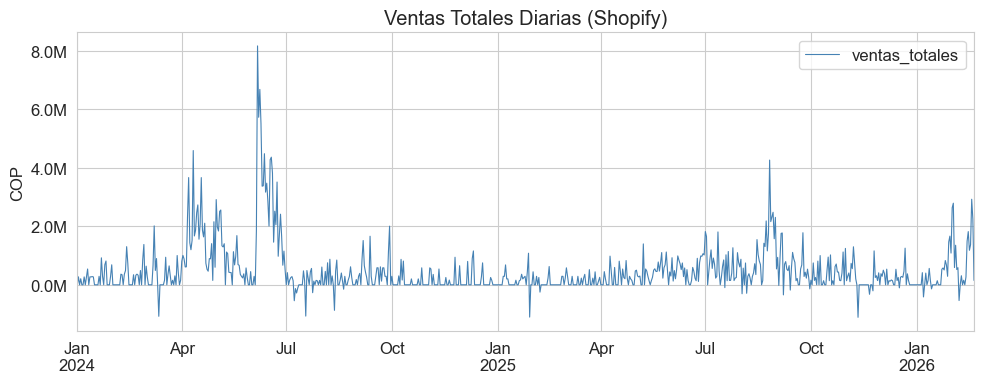


Medidas de tendencia central para ventas diarias:
  • Media: 483829.71  COP
  • Mediana: 227940.00 COP

Medidas de dispersión para ventas diarias:
  • Desviación estándar: 852447.59 COP
  • Mínimo: -1111320.00 COP
  • Máximo: 8165350.00 COP
  • Rango: 9276670.00 COP
  • Rango intercuartílico (IQR): 611070.00 COP

Resumén de ventas diarias por rangos:
  • Ventas diarias menores a 0: 25 registros
  • Ventas diarias iguales a 0: 290 registros
  • Ventas diarias mayores a 0: 467 registros

Medidas de tendencia central para ventas diarias mayores a 0:
  • Media: 831768.88 COP
  • Mediana: 529600.00COP

Medidas de dispersión para ventas diarias mayores a 0:
  • Desviación estándar: 949833.38 COP
  • Mínimo: 105000.00 COP
  • Máximo: 8165350.00 COP
  • Rango: 8060350.00 COP
  • Rango intercuartílico (IQR): 690069.00 COP


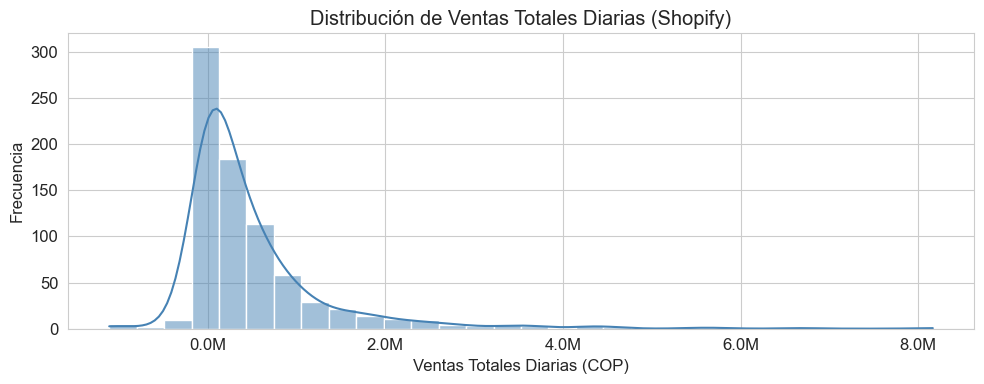

In [6]:
# Visualización de variables claves

# Gráfico 1

# Ventas diarias en el tiempo, traídas del dataset 07_ventas_diarias_completas_shopify.csv

fig, ax = plt.subplots(figsize=(10, 4))

vs.plot(
    x='fecha',
    y='ventas_totales',
    ax=ax,
    color='steelblue',
    linewidth=0.8
)

ax.set_title('Ventas Totales Diarias (Shopify)')
ax.set_xlabel('')
ax.set_ylabel('COP')
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M')
)

plt.tight_layout()
plt.savefig('./graficos/ventas_diarias.png', dpi=150, bbox_inches='tight')
plt.show()

# Cálcuo de medidas de tendendia central para las ventas diarias
print(f"\nMedidas de tendencia central para ventas diarias:")
print(f"  • Media: {vs['ventas_totales'].mean():.2f}  COP")
print(f"  • Mediana: {vs['ventas_totales'].median():.2f} COP")

# Cálculo de medidas de dispersion para las ventas diarias
print(f"\nMedidas de dispersión para ventas diarias:")
print(f"  • Desviación estándar: {vs['ventas_totales'].std():.2f} COP")
print(f"  • Mínimo: {vs['ventas_totales'].min():.2f} COP")
print(f"  • Máximo: {vs['ventas_totales'].max():.2f} COP")
print(f"  • Rango: {(vs['ventas_totales'].max() - vs['ventas_totales'].min()):.2f} COP")
print(f"  • Rango intercuartílico (IQR): {(vs['ventas_totales'].quantile(0.75) - vs['ventas_totales'].quantile(0.25)):.2f} COP")

# Tabla resumén de ventas diarias < 0, para identificar posibles errores o anomalías en los datos, establecer rangos para las ventas mayores de 0, y analizar la distribución de las ventas diarias en el tiempo.
print(f"\nResumén de ventas diarias por rangos:")
vs_negativas = vs[vs['ventas_totales'] < 0]
print(f"  • Ventas diarias menores a 0: {len(vs_negativas)} registros")
vs_cero = vs[vs['ventas_totales'] == 0]
print(f"  • Ventas diarias iguales a 0: {len(vs_cero)} registros")
vs_positivas = vs[vs['ventas_totales'] > 0]
print(f"  • Ventas diarias mayores a 0: {len(vs_positivas)} registros")

# Cálculo de medidas de tendendia central para las ventas diarias mayores a 0
print(f"\nMedidas de tendencia central para ventas diarias mayores a 0:")
print(f"  • Media: {vs_positivas['ventas_totales'].mean():.2f} COP")
print(f"  • Mediana: {vs_positivas['ventas_totales'].median():.2f}COP")

# Cálculo de medidas de dispersión para las ventas diarias mayores a 0
print(f"\nMedidas de dispersión para ventas diarias mayores a 0:")
print(f"  • Desviación estándar: {vs_positivas['ventas_totales'].std():.2f} COP")
print(f"  • Mínimo: {vs_positivas['ventas_totales'].min():.2f} COP")
print(f"  • Máximo: {vs_positivas['ventas_totales'].max():.2f} COP")
print(f"  • Rango: {(vs_positivas['ventas_totales'].max() - vs_positivas['ventas_totales'].min()):.2f} COP")
print(f"  • Rango intercuartílico (IQR): {(vs_positivas['ventas_totales'].quantile(0.75) - vs_positivas['ventas_totales'].quantile(0.25)):.2f} COP")

# Gráfico 1.1. Ventas diarias por rangos
fig, ax = plt.subplots(figsize=(10, 4)) 
sns.histplot(vs['ventas_totales'], bins=30, kde=True, ax=ax, color='steelblue')
ax.set_title('Distribución de Ventas Totales Diarias (Shopify)')
ax.set_xlabel('Ventas Totales Diarias (COP)')
ax.set_ylabel('Frecuencia')
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M')
)
plt.tight_layout()
plt.savefig('./graficos/distribucion_ventas_diarias.png', dpi=150, bbox_inches='tight')
plt.show()

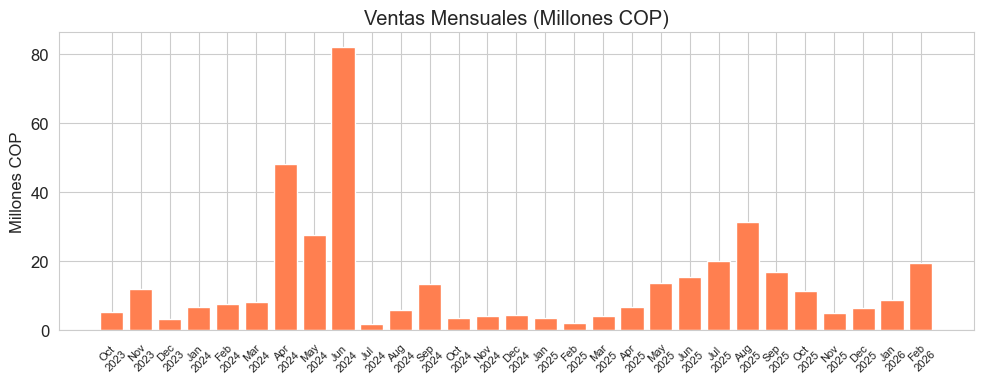

Promedio de ventas mensuales: 13.74 millones COP
Desviación estándar de ventas mensuales: 16.65 millones COP
Volatilidad mensual (std/mean): 1.21

Top 5 meses con mayores ventas:


,nombre_mes,anio,ventas_totales
8,June,2024,82024518.0
6,April,2024,48069390.0
22,August,2025,31399566.0
7,May,2024,27622550.0
21,July,2025,19974330.0


Meses considerados outliers en ventas mensuales:


,nombre_mes,anio,ventas_totales
6,April,2024,48069390.0
8,June,2024,82024518.0


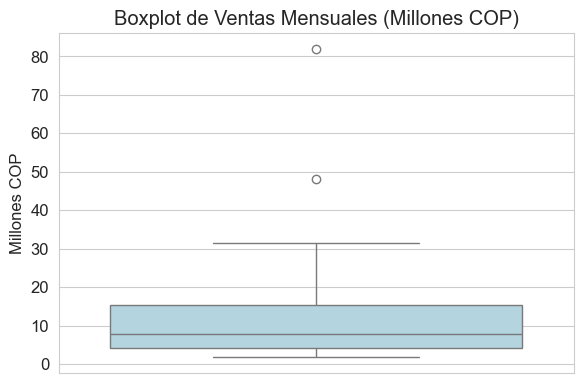

In [7]:
# Gráfico 2

# Ventas mensuales en el tiempo, traídas del dataset 06_ventas_mensuales_completas.csv

fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(
    range(len(vm)),
    vm['ventas_totales'] / 1e6,
    color='coral'
)

ax.set_xticks(range(len(vm)))
ax.set_xticklabels(
    [f"{r['nombre_mes'][:3]}\n{r['anio']}" for _, r in vm.iterrows()],
    fontsize=8,
    rotation=45
)

ax.set_title('Ventas Mensuales (Millones COP)')
ax.set_ylabel('Millones COP')

plt.tight_layout()
plt.savefig('./graficos/ventas_mensuales.png', dpi=150, bbox_inches='tight')
plt.show()

# Promedio de ventas mensuales, traídas del dataset 06_ventas_mensuales_completas.csv
avg_monthly_sales = vm['ventas_totales'].mean()
print(f"Promedio de ventas mensuales: {avg_monthly_sales/1e6:.2f} millones COP")
std_monthly_sales = vm['ventas_totales'].std()
print(f"Desviación estándar de ventas mensuales: {std_monthly_sales/1e6:.2f} millones COP")
print(f"Volatilidad mensual (std/mean): {std_monthly_sales/avg_monthly_sales:.2f}")

# Tabla de ventas mensuales ordenadas de mayor a menor, traídas del dataset 06_ventas_mensuales_completas.csv
vm_sorted = vm.sort_values(by='ventas_totales', ascending=False)
print("")
print("Top 5 meses con mayores ventas:")
display(vm_sorted[['nombre_mes', 'anio', 'ventas_totales']].head())

# Outliers en ventas mensuales, traídas del dataset 06_ventas_mensuales_completas.csv
Q1 = vm['ventas_totales'].quantile(0.25)
Q3 = vm['ventas_totales'].quantile(0.75)
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup= Q3 + 1.5 * IQR
outliers = vm[(vm['ventas_totales'] < lim_inf) | (vm['ventas_totales'] > lim_sup)]
print(f"Meses considerados outliers en ventas mensuales:")
display(outliers[['nombre_mes', 'anio', 'ventas_totales']])

# Grafica de boxplot de ventas mensuales para visualizar la distribución y outliers, traídas del dataset 06_ventas_mensuales_completas.csv
plt.figure(figsize=(6, 4))
sns.boxplot(y=vm['ventas_totales'] / 1e6, color='lightblue')
plt.title('Boxplot de Ventas Mensuales (Millones COP)')
plt.ylabel('Millones COP')
plt.tight_layout()
plt.savefig('./graficos/boxplot_ventas_mensuales.png', dpi=150, bbox_inches='tight')
plt.show()

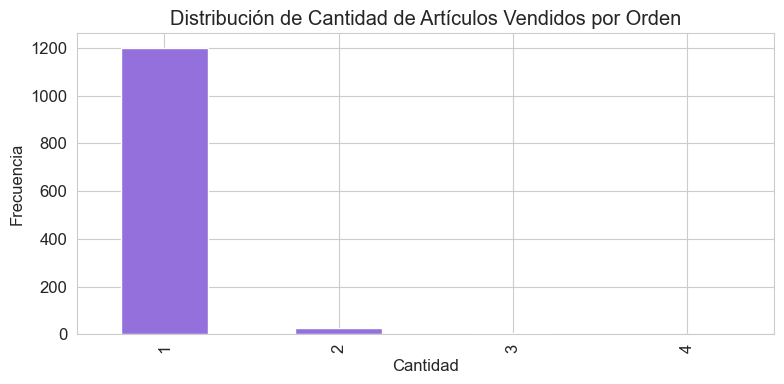

In [8]:
# Gráfico 3

# Distribución de cantidad de artículos vendidos por orden, traídos del dataset 01_ordenes_limpias.csv

fig, ax = plt.subplots(figsize=(8, 4))

ordenes['cantidad'] \
    .value_counts() \
    .sort_index() \
    .plot(kind='bar', ax=ax, color='mediumpurple')

ax.set_title('Distribución de Cantidad de Artículos Vendidos por Orden')
ax.set_xlabel('Cantidad')
ax.set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig('./graficos/ventas_orden.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Tabla de frecuencia de cantidad de artículos vendidos por orden, traídos del dataset 01_ordenes_limpias.csv
cantidad_frecuencia = ordenes['cantidad'].value_counts().reset_index()
cantidad_frecuencia.columns = ['cantidad', 'frecuencia']
print("Frecuencia de cantidad de artículos vendidos por orden:")
display(cantidad_frecuencia.sort_values(by='cantidad'))

Frecuencia de cantidad de artículos vendidos por orden:


,cantidad,frecuencia
0,1,1201
1,2,29
2,3,5
3,4,1


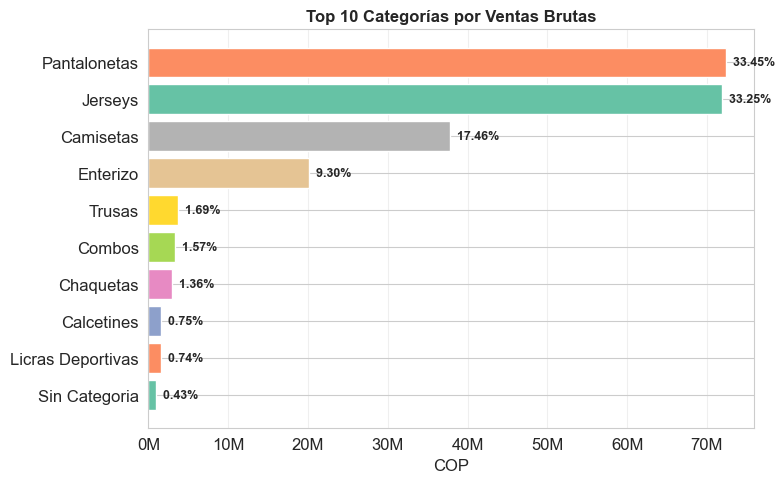

In [40]:
# Gráfico 4

# Ventas por categoría de producto, traídos del dataset 01_ordenes_limpias.csv

cat_ventas = (
    ordenes
    .groupby('categoria_producto')
    .apply(lambda x: (x['precio_unitario'] * x['cantidad']).sum())
    .sort_values(ascending=True)
    .tail(10)
)

# Calcular porcentaje sobre el total del Top 10
total_ventas = cat_ventas.sum()
porcentajes = (cat_ventas / total_ventas) * 100


# Gráficas por unidades vendidas
#cat_ventas = (
#     ordenes
#    .groupby('categoria_producto')['cantidad']
#    .sum()
#    .sort_values(ascending=True)
#    .tail(10)
#)

# Calcular porcentaje sobre el total del Top 10
total_unidades = cat_ventas.sum()
porcentajes = (cat_ventas / total_unidades) * 100

# Paleta de colores (uno por barra)
colores = sns.color_palette('Set2', len(cat_ventas))

# Crear gráfico
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.barh(
    cat_ventas.index,
    cat_ventas.values,
    color=colores
)

# Formato eje X en millones
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, p: f'{x/1e6:.0f}M')
)

ax.set_title('Top 10 Categorías por Ventas Brutas', fontsize=12, fontweight='bold')
ax.set_xlabel('COP')

# Agregar porcentaje con dos decimales sobre cada barra
for bar, pct in zip(bars, porcentajes):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f'  {pct:.2f}%',
        va='center',
        ha='left',
        fontsize=9,
        fontweight='bold'
    )

ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('./graficos/ventas_top10_categoria.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# ===========================
# Tabla resumen por categoría
# ===========================

tabla_resumen = (
    ordenes
    .assign(
        venta_total=lambda x: x['cantidad'] * x['precio_unitario']
    )
    .groupby('categoria_producto', as_index=False)
    .agg(
        unidades_vendidas=('cantidad', 'sum'),
        total_ventas=('venta_total', 'sum'),
        precio_promedio_unitario=('precio_unitario', 'mean')
    )
    .sort_values('total_ventas', ascending=False)
    .head(10)
)

# Porcentaje sobre el total del Top 10
total_ventas_top10 = tabla_resumen['total_ventas'].sum()
tabla_resumen['porcentaje_sobre_total'] = (
    tabla_resumen['total_ventas'] / total_ventas_top10 * 100
)

# Formato opcional para presentación
tabla_resumen['total_ventas'] = tabla_resumen['total_ventas'].round(0)
tabla_resumen['precio_promedio_unitario'] = tabla_resumen['precio_promedio_unitario'].round(2)
tabla_resumen['porcentaje_sobre_total'] = tabla_resumen['porcentaje_sobre_total'].round(2)

tabla_resumen

,categoria_producto,unidades_vendidas,total_ventas,precio_promedio_unitario,porcentaje_sobre_total
13,Pantalonetas,280,72333640.0,260596.51,33.45
10,Jerseys,515,71913340.0,140358.86,33.25
3,Camisetas,264,37761600.0,143837.50,17.46
8,Enterizo,73,20119930.0,274139.31,9.30
16,Trusas,20,3662900.0,184636.84,1.69
7,Combos,25,3387500.0,135733.33,1.57
5,Chaquetas,17,2942440.0,173084.71,1.36
2,Calcetines,55,1612000.0,29309.09,0.75
11,Licras Deportivas,12,1598800.0,132990.91,0.74
15,Sin Categoria,4,929600.0,232400.00,0.43


In [12]:
# Tabla de ventas por categoría de producto
# (excluyendo devoluciones: ventas > 0)

# ✅ Filtrar solo registros con ventas positivas
ordenes_ventas_positivas = ordenes[ordenes['cantidad'] > 0]

# ✅ Agrupar y calcular métricas
ventas_por_categoria = (
    ordenes_ventas_positivas
    .groupby('categoria_producto')
    .agg(
        unidades_vendidas=('cantidad', 'sum'),
        total_ventas=('precio_unitario',
            lambda x: (x * ordenes_ventas_positivas.loc[x.index, 'cantidad']).sum()
        ),
        promedio_venta_unitaria=('precio_unitario', 'mean')
    )
)

# ✅ Total general de ventas (solo ventas > 0)
total_general_ventas = ventas_por_categoria['total_ventas'].sum()

# ✅ Porcentaje sobre el total
ventas_por_categoria['porcentaje_total_ventas (%)'] = (
    ventas_por_categoria['total_ventas'] / total_general_ventas * 100
)

# ✅ Ordenar por total de ventas
ventas_por_categoria = ventas_por_categoria.sort_values(
    by='total_ventas',
    ascending=False
)

print("Ventas por categoría de producto (solo ventas > 0):")
display(ventas_por_categoria)

Ventas por categoría de producto (solo ventas > 0):


,unidades_vendidas,total_ventas,promedio_venta_unitaria,porcentaje_total_ventas (%)
categoria_producto,,,,
Pantalonetas,280,72333640.0,260596.509091,33.270850
Jerseys,515,71913340.0,140358.857143,33.077528
Camisetas,264,37761600.0,143837.500000,17.368966
Enterizo,73,20119930.0,274139.305556,9.254438
Trusas,20,3662900.0,184636.842105,1.684801
Combos,25,3387500.0,135733.333333,1.558127
Chaquetas,17,2942440.0,173084.705882,1.353416
Calcetines,55,1612000.0,29309.090909,0.741462
Licras Deportivas,12,1598800.0,132990.909091,0.735390


In [13]:
# Tabla de ventas por producto

# Calculamos unidades vendidas y totales en COP por producto, top 30 productos

ventas_por_producto = ordenes.groupby('producto').agg(
    unidades_vendidas=('cantidad', 'sum'),
    total_ventas=('precio_unitario', lambda x: (x * ordenes.loc[x.index, 'cantidad']).sum()),
    promedio_venta_unitaria=('precio_unitario', 'mean')
#).sort_values(by='total_ventas', ascending=False).head(30)
).sort_values(by='total_ventas', ascending=False)

print("Ventas por producto (ordenadas por total de ventas descendente):")
# print("Top 30 - Ventas por producto (ordenadas por total de ventas descendente):")
display(ventas_por_producto)

Ventas por producto (ordenadas por total de ventas descendente):


,unidades_vendidas,total_ventas,promedio_venta_unitaria
producto,,,
Pantaloneta Estelar - M,27,7827300.0,289900.0
Enterizo Manga Corta - M,24,5470560.0,227940.0
Pantaloneta Estelar - S,16,4638400.0,289900.0
Camiseta Tour de Francia azul hombre - M / Manga corta,34,4246600.0,124900.0
Pantaloneta Estelar - L,13,3768700.0,289900.0
...,...,...,...
Calcetines tejidos - XL / Dark blue,1,27800.0,27800.0
Calcetines tejidos - XL / Neon,1,27800.0,27800.0
Calcetines tejidos - XL / Red whine,1,27800.0,27800.0


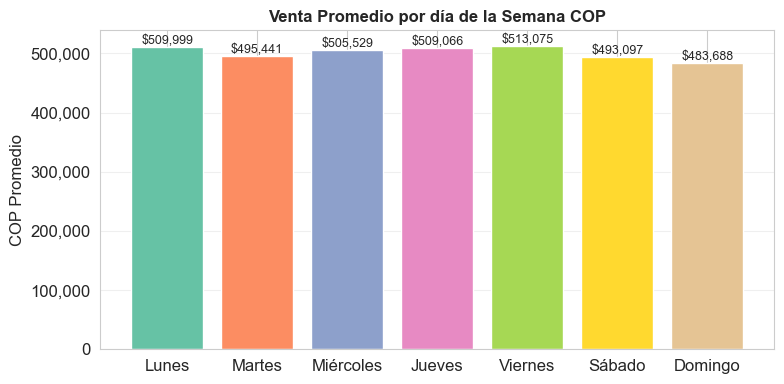

In [14]:
# Gráfico 5

# Ventas promedio por día de la semana, traídos del dataset 02_ventas_diarias.csv

# Calcular ventas promedio por día (ordenadas)
ventas_promedio = (
    vd.groupby('dia_semana')['ventas_totales']
      .mean()
      .reindex([0, 1, 2, 3, 4, 5, 6])  # Asegura orden Lun–Dom
)

dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
colores = sns.color_palette('Set2', len(ventas_promedio))

fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(
    dias,
    ventas_promedio.values,
    color=colores
)

# Formato eje Y en millones
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, p: f'{x:,.0f}' if x < 1e6 else f'{x/1e6:,.0f} M COP')
)

# Títulos y etiquetas
ax.set_title('Venta Promedio por día de la Semana COP', fontsize=12, fontweight='bold')
ax.set_ylabel('COP Promedio')

# Etiquetas encima de cada barra
for bar, value in zip(bars, ventas_promedio.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'${value:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('./graficos/ventas_promedio_dia_semana.png', dpi=150, bbox_inches='tight')
plt.show()


In [15]:
# Tabla de Ventas promedio por día de la semana, traídos del dataset 02_ventas_diarias.csv
ventas_dia_semana = vd.groupby('dia_semana')['ventas_totales'].mean().reset_index()
ventas_dia_semana['dia_semana'] = ventas_dia_semana['dia_semana'].map({0: 'Lunes', 1: 'Martes', 2: 'Miércoles', 3: 'Jueves', 4: 'Viernes', 5: 'Sábado', 6: 'Domingo'})
print("Ventas promedio por día de la semana:")
display(ventas_dia_semana)

Ventas promedio por día de la semana:


,dia_semana,ventas_totales
0,Lunes,509998.838710
1,Martes,495441.428571
2,Miércoles,505528.606452
3,Jueves,509066.217391
4,Viernes,513075.383333
5,Sábado,493096.983051
6,Domingo,483687.836364


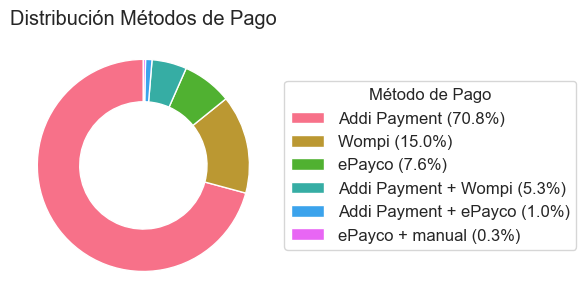

In [16]:
# Gráfico 6

# Métodos de pago más utilizados, traídos del dataset 01_ordenes_limpias.csv

fig, ax = plt.subplots(figsize=(6, 6))

# Datos
pago_counts = ordenes['payment_method'].value_counts().head(6)

# Cálculo de porcentajes
porcentajes = pago_counts / pago_counts.sum() * 100

# Gráfico tipo donut
ax.pie(
    pago_counts,
    startangle=90,
    wedgeprops={'width': 0.4, 'edgecolor': 'white'}
)

# Etiquetas de leyenda con porcentaje
labels = [
    f"{metodo} ({pct:.1f}%)"
    for metodo, pct in zip(pago_counts.index, porcentajes)
]

# Leyenda externa
ax.legend(
    labels,
    title='Método de Pago',
    loc='center left',
    bbox_to_anchor=(1, 0.5)
)

ax.set_title('Distribución Métodos de Pago')

plt.tight_layout()
plt.savefig('./graficos/metodos_pago.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# Hallazgos claves del Dataset 01_ordenes_limpias.csv
print("📌 Hallazgos claves del Dataset Ordenes Limpias")
print("─" * 60)
print(f"  • Período analizado: Oct 2023 → Feb 2026 ({len(vm)} meses)")
print(f"  • Top cuatro (4) categorías: Jersey, Pantalonetas, Camisetas, Enterizos")
print(f"  • Método de pago dominante: Addi Payment (70.8%)")
print(f"  • Canal principal: web ({ordenes['canal'].value_counts().iloc[0]/len(ordenes)*100:.1f}% de órdenes)")
print(f"  • Cantidad de artículos vendidos por orden: casi siempre 1 unidad ({ordenes[ordenes['cantidad']==1].shape[0]/len(ordenes)*100:.1f}%), de 1236 ordenes, en 1201 sólo se vendió 1 unidad")
print(f"  • Picos de venta: Junio 2024 (82M COP) y Abril 2024 (48M COP) como outliers; Agosto 2025 (31M COP), ")
print(f"    Mayo 2024 (27.6M COP) y Julio 2025 (19.97M COP) completan el TOP 5 meses con mayores ventas")
print(f"  • Promedio de ventas mensuales: {avg_monthly_sales/1e6:.2f} millones COP")
print(f"  • Alta volatilidad mensual: std = {vm['ventas_totales'].std()/1e6:.1f}M COP")
print(f"\n💡 DECISIÓN DE DISEÑO DEL MODELO:")
print("   → La cantidad por orden, la cuál está comprendieda entre 1 y 4 unidades,")
print("     media=1.03) tiene varianza muy baja")
print("   → Se modelará 'ventas_totales' diarias (COP) como variable objetivo")
print("   → Fuente: 07_ventas_diarias_completas_shopify.csv (782 días, más features)")

📌 Hallazgos claves del Dataset Ordenes Limpias
────────────────────────────────────────────────────────────
  • Período analizado: Oct 2023 → Feb 2026 (29 meses)
  • Top cuatro (4) categorías: Jersey, Pantalonetas, Camisetas, Enterizos
  • Método de pago dominante: Addi Payment (70.8%)
  • Canal principal: web (98.2% de órdenes)
  • Cantidad de artículos vendidos por orden: casi siempre 1 unidad (97.2%), de 1236 ordenes, en 1201 sólo se vendió 1 unidad
  • Picos de venta: Junio 2024 (82M COP) y Abril 2024 (48M COP) como outliers; Agosto 2025 (31M COP), 
    Mayo 2024 (27.6M COP) y Julio 2025 (19.97M COP) completan el TOP 5 meses con mayores ventas
  • Promedio de ventas mensuales: 13.74 millones COP
  • Alta volatilidad mensual: std = 16.6M COP

💡 DECISIÓN DE DISEÑO DEL MODELO:
   → La cantidad por orden, la cuál está comprendieda entre 1 y 4 unidades,
     media=1.03) tiene varianza muy baja
   → Se modelará 'ventas_totales' diarias (COP) como variable objetivo
   → Fuente: 07_ventas_

# 5. Preparación de datos

La normalización para el modelo de Machine Learning seleccionado Gradient Boosting no es necesaria o no aplica debido a:

    No depende de distancias
    No usa gradiente descendente en el espacio de las variables
    Divide el espacio mediante umbrales, no por magnitudes

✅ Por tanto:

    Variables como ventas en miles y variables binarias pueden coexistir
    Se evita una etapa adicional de preprocesamiento
    Se reduce el riesgo de errores como data leakage por escalado incorrecto

Esto simplifica el pipeline y aumenta la reproducibilidad del modelo.

# Razón de elegibilidad del modelo:

Se eligió el modelo de Gradient Boosting debido a su alta capacidad para modelar relaciones no lineales, su robustez frente a valores atípicos y el excelente desempeño en el dataset de ventas diarias Shopify, el cual tiene 782 registros. Estas características lo hacen especialmente adecuado para la predicción de ventas diarias de la empresa Eleve Pro, donde existen efectos temporales, estacionalidad implícita y variabilidad significativa en el comportamiento de las ventas.



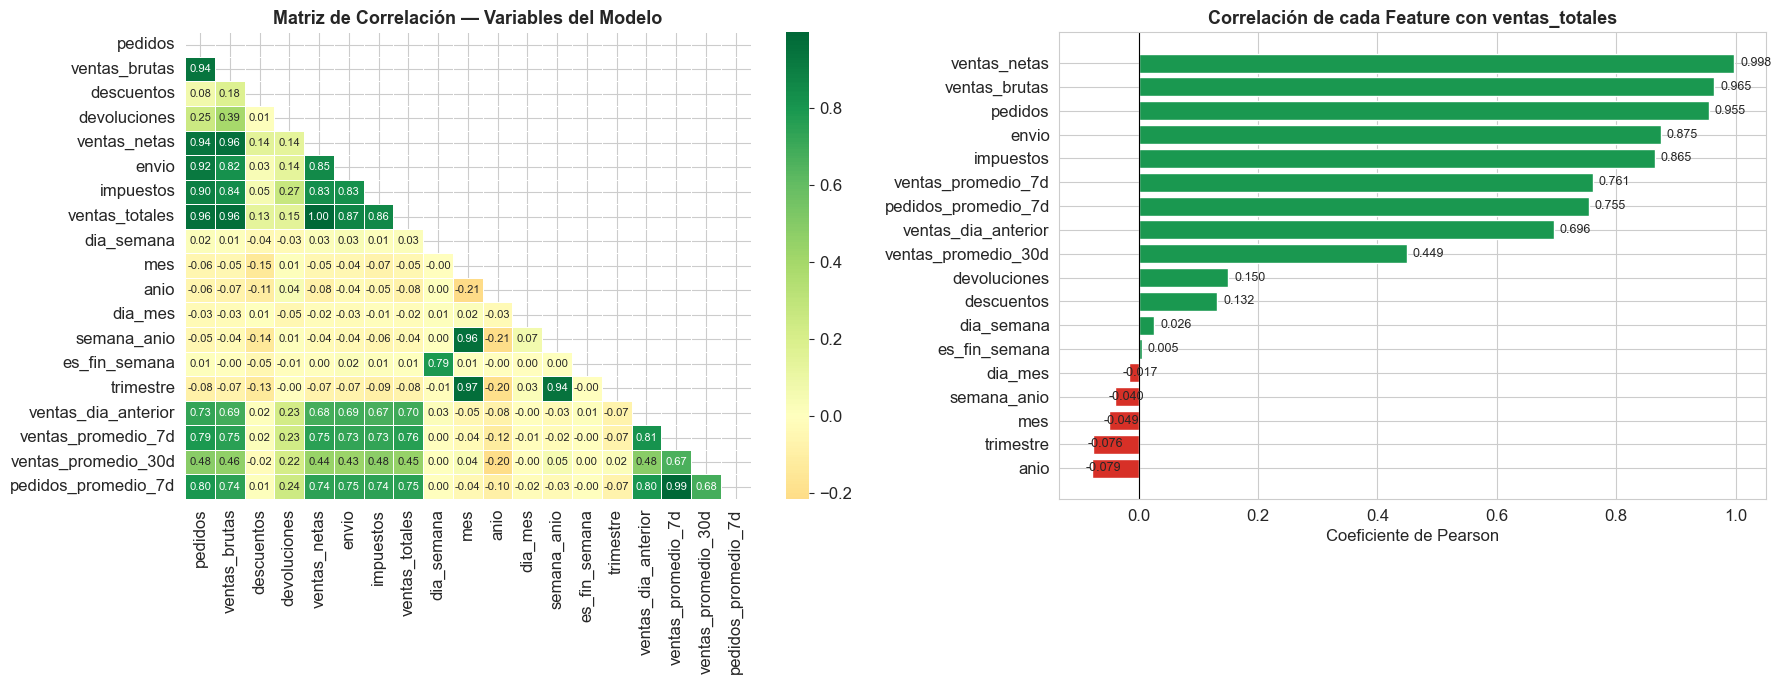


🎯 Correlación de cada variable con ventas_totales:
   🟢 ventas_netas: 0.9978
   🟢 ventas_brutas: 0.9647
   🟢 pedidos: 0.9553
   🟢 envio: 0.8746
   🟢 impuestos: 0.8648
   🟢 ventas_promedio_7d: 0.7608
   🟢 pedidos_promedio_7d: 0.7545
   🟢 ventas_dia_anterior: 0.6956
   🟢 ventas_promedio_30d: 0.4489
   🟡 devoluciones: 0.1501
   🟡 descuentos: 0.1318
   🔴 dia_semana: 0.0260
   🔴 es_fin_semana: 0.0050
   🔴 dia_mes: -0.0168
   🔴 semana_anio: -0.0398
   🔴 mes: -0.0490
   🔴 trimestre: -0.0757
   🔴 anio: -0.0786


In [18]:
# Definición de features y variable objetivo

# Features
FEATURES = [
    'pedidos',              # número de órdenes del día
    'descuentos',           # total de descuentos aplicados
    'devoluciones',         # devoluciones del día
    'dia_semana',           # 0=Lunes ... 6=Domingo
    'mes',                  # 1-12
    'anio',                 
    'dia_mes',              
    'semana_anio',          
    'es_fin_semana',        # binaria 0/1
    'trimestre',            
    'ventas_dia_anterior',  # lag-1
    'ventas_promedio_7d',   # media móvil 7 días
    'ventas_promedio_30d',  # media móvil 30 días
    'pedidos_promedio_7d',  # media móvil pedidos 7 días
]

TARGET = 'ventas_totales'  # Variable objetivo

# Seleccionar solo columnas numéricas para la correlación
numeric_vs = vs.select_dtypes(include=[np.number])
corr_matrix = numeric_vs.corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Heatmap completo
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, ax=axes[0],
            linewidths=0.5, annot_kws={'size': 8})
axes[0].set_title('Matriz de Correlación — Variables del Modelo', fontsize=13, fontweight='bold')

# Barras de correlación con la variable objetivo
corr_target = corr_matrix[TARGET].drop(TARGET).sort_values()
colors = ['#d73027' if v < 0 else '#1a9850' for v in corr_target.values]
axes[1].barh(corr_target.index, corr_target.values, color=colors)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title(f'Correlación de cada Feature con {TARGET}', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Coeficiente de Pearson')

for i, v in enumerate(corr_target.values):
    axes[1].text(v + 0.01*(1 if v >= 0 else -1), i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('./graficos/correlacion_eleven_pro.png', dpi=150, bbox_inches='tight')
plt.show()

# Top correlaciones con la variable objetivo
print("\n🎯 Correlación de cada variable con ventas_totales:")
correlaciones = corr_matrix['ventas_totales'].drop('ventas_totales').sort_values(ascending=False)
for var, corr in correlaciones.items():
    emoji = "🟢" if abs(corr) > 0.3 else "🟡" if abs(corr) > 0.1 else "🔴"
    print(f"   {emoji} {var}: {corr:.4f}")

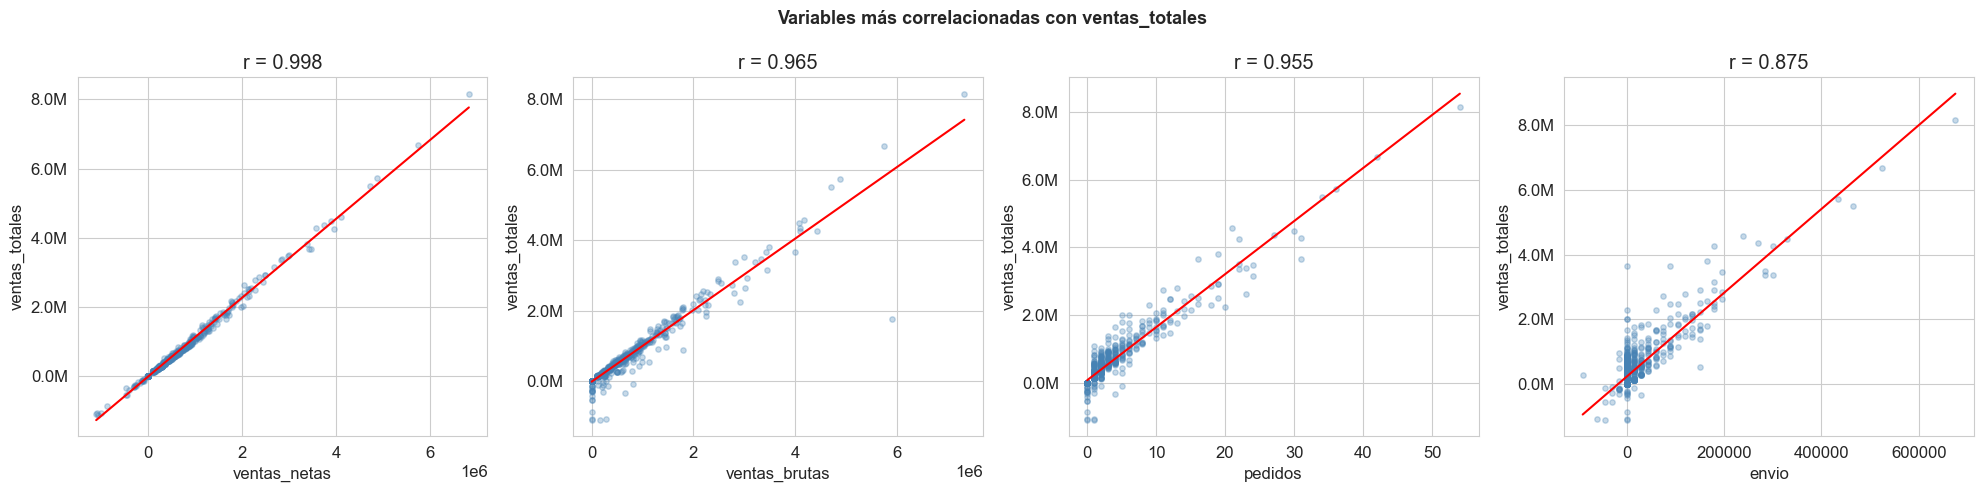


💡 'pedidos' tiene la correlación más alta (r ≈ 0.998) → variable más predictiva


In [19]:
# Scatterplots de las 4 variables más correlacionadas
top4 = corr_target.abs().sort_values(ascending=False).head(4).index.tolist()

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Variables más correlacionadas con ventas_totales', fontsize=13, fontweight='bold')
for ax, feat in zip(axes, top4):
    ax.scatter(vs[feat], vs[TARGET], alpha=0.3, s=15, color='steelblue')
    m, b = np.polyfit(vs[feat], vs[TARGET], 1)
    ax.plot(np.sort(vs[feat]), m*np.sort(vs[feat])+b, 'r-', linewidth=1.5)
    ax.set_xlabel(feat)
    ax.set_ylabel('ventas_totales')
    ax.set_title(f'r = {corr_matrix.loc[feat, TARGET]:.3f}')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.show()
print("\n💡 'pedidos' tiene la correlación más alta (r ≈ 0.998) → variable más predictiva")

# 6. Modelo(s) aplicado(s)

# 6.1. Regresión Lineal Simple

In [20]:
# Definición de features y variable objetivo para el modelo de regresión lineal simple
# Pedidos → ventas_totales (COP)
# pedidos variable predictoria (X)
# ventas_totales variable objetivo (y)

X_rl = vs[['pedidos']]
y_rl  = vs['ventas_totales']

# División train/test (80/20)
X_train_rl, X_test_rl, y_train_rl, y_test_rl = train_test_split(
    X_rl, y_rl, test_size=0.2, random_state=42
)

print(f"📊 Datos de entrenamiento: {X_train_rl.shape[0]} filas")
print(f"📊 Datos de prueba: {X_test_rl.shape[0]} filas")

📊 Datos de entrenamiento: 625 filas
📊 Datos de prueba: 157 filas


REGRESIÓN LINEAL SIMPLE: Pedidos → Ventas Totales

📐 Intercepto (β₀): 74,403
📐 Pendiente  (β₁): 158,190

📊 R² en entrenamiento: 0.9236
📊 R² en prueba:        0.8508

💡 INTERPRETACIÓN:

  Ecuación del modelo:
  ventas_totales = 158,190 × pedidos + 74,403

  Interpretación:
  → Por cada pedido adicional, las ventas suben $ 158,190 COP
   El modelo explica el 85.08% de la variabilidad

  Métricas de evaluación (test 20%):
  MAE  :         169,906 COP  ---> Promedio de error absoluto entre las ventas reales y las predichas por el modelo
  RMSE :         293,143 COP ---> Raíz del error cuadrático medio, penaliza más los errores grandes
  R²   :          0.8508  ---> Proporción de la varianza explicada por el modelo en el conjunto de prueba
  CV R²:          0.7959  (5-fold cross-validation) ---> Promedio de R² en validación cruzada, indica la estabilidad del modelo


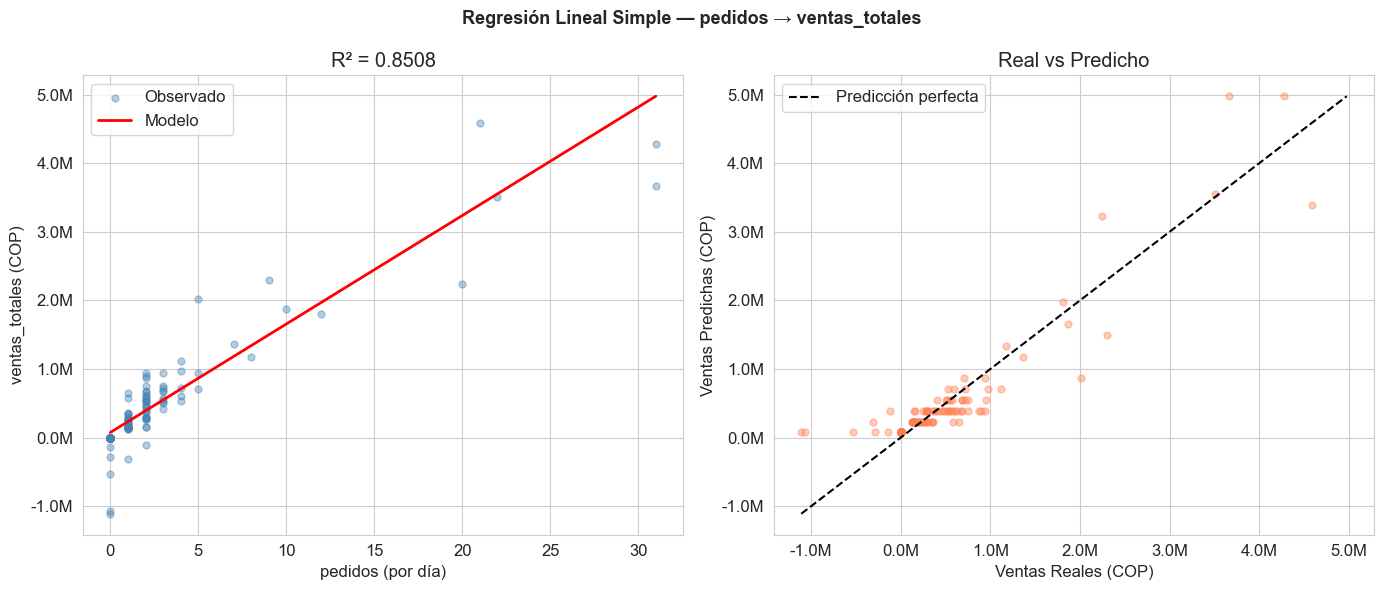

In [21]:
# Entrenamiento del modelo de regresión lineal simple

modelo_simple = LinearRegression()
modelo_simple.fit(X_train_rl, y_train_rl)

# Resultados
print("=" * 50)
print("REGRESIÓN LINEAL SIMPLE: Pedidos → Ventas Totales")
print("=" * 50)
print(f"\n📐 Intercepto (β₀): {modelo_simple.intercept_:,.0f}")
print(f"📐 Pendiente  (β₁): {modelo_simple.coef_[0]:,.0f}")
print(f"\n📊 R² en entrenamiento: {modelo_simple.score(X_train_rl, y_train_rl):.4f}")
print(f"📊 R² en prueba:        {modelo_simple.score(X_test_rl, y_test_rl):.4f}")

print(f"\n💡 INTERPRETACIÓN:")
print(f"\n  Ecuación del modelo:")
print(f"  ventas_totales = {modelo_simple.coef_[0]:,.0f} × pedidos + {modelo_simple.intercept_:,.0f}")
print(f"\n  Interpretación:")
print(f"  → Por cada pedido adicional, las ventas suben $ {modelo_simple.coef_[0]:,.0f} COP")
print(f"   El modelo explica el {modelo_simple.score(X_test_rl, y_test_rl)*100:.2f}% de la variabilidad")

y_pred_rl = modelo_simple.predict(X_test_rl)

# Métricas de evaluación
mae_rl  = mean_absolute_error(y_test_rl, y_pred_rl)
rmse_rl = np.sqrt(mean_squared_error(y_test_rl, y_pred_rl))
r2_rl   = r2_score(y_test_rl, y_pred_rl)
cv_rl   = cross_val_score(modelo_simple, X_rl, y_rl, cv=5, scoring='r2').mean()


print(f"\n  Métricas de evaluación (test 20%):")
print(f"  MAE  : {mae_rl:>15,.0f} COP  ---> Promedio de error absoluto entre las ventas reales y las predichas por el modelo")
print(f"  RMSE : {rmse_rl:>15,.0f} COP ---> Raíz del error cuadrático medio, penaliza más los errores grandes")
print(f"  R²   : {r2_rl:>15,.4f}  ---> Proporción de la varianza explicada por el modelo en el conjunto de prueba")
print(f"  CV R²: {cv_rl:>15,.4f}  (5-fold cross-validation) ---> Promedio de R² en validación cruzada, indica la estabilidad del modelo")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Regresión Lineal Simple — pedidos → ventas_totales', fontsize=13, fontweight='bold')

# Scatter + recta de regresión
axes[0].scatter(X_test_rl, y_test_rl, alpha=0.4, s=25, label='Observado', color='steelblue')
x_line = np.linspace(X_test_rl['pedidos'].min(), X_test_rl['pedidos'].max(), 100).reshape(-1,1)
axes[0].plot(x_line, modelo_simple.predict(x_line), 'r-', linewidth=2, label='Modelo')
axes[0].set_xlabel('pedidos (por día)')
axes[0].set_ylabel('ventas_totales (COP)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'{x/1e6:.1f}M'))
axes[0].legend()
axes[0].set_title(f'R² = {r2_rl:.4f}')

# Real vs Predicho
axes[1].scatter(y_test_rl, y_pred_rl, alpha=0.4, s=25, color='coral')
lims = [min(y_test_rl.min(), y_pred_rl.min()), max(y_test_rl.max(), y_pred_rl.max())]
axes[1].plot(lims, lims, 'k--', linewidth=1.5, label='Predicción perfecta')
axes[1].set_xlabel('Ventas Reales (COP)')
axes[1].set_ylabel('Ventas Predichas (COP)')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'{x/1e6:.1f}M'))
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'{x/1e6:.1f}M'))
axes[1].set_title('Real vs Predicho')
axes[1].legend()

plt.tight_layout()
plt.savefig('./graficos/regresion_simple.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.2. Regresión Lineal Múltiple

Ahora incorporamos **todas las variables** disponibles para mejorar la predicción.

> **Hipótesis:** Con más variables temporales y de contexto, el modelo explicará más variabilidad en las ventas.

  REGRESIÓN LINEAL MÚLTIPLE
  Variables predictoras: 14
  Variable objetivo    : ventas_totales

  Coeficientes del modelo:
    pedidos                              162,786 COP
    pedidos_promedio_7d                 -140,898 COP
    anio                                  26,324 COP
    es_fin_semana                        -16,566 COP
    trimestre                             14,791 COP
    dia_semana                             5,188 COP
    mes                                   -4,500 COP
    semana_anio                              865 COP
    dia_mes                                  234 COP
    descuentos                                 1 COP
    ventas_promedio_7d                         1 COP
    devoluciones                              -0 COP
    ventas_promedio_30d                        0 COP
    ventas_dia_anterior                       -0 COP
    Intercepto                       -53,337,839 COP

📊 R² en entrenamiento: 0.9410
📊 R² en prueba:        0.8973

  Más Métricas de e

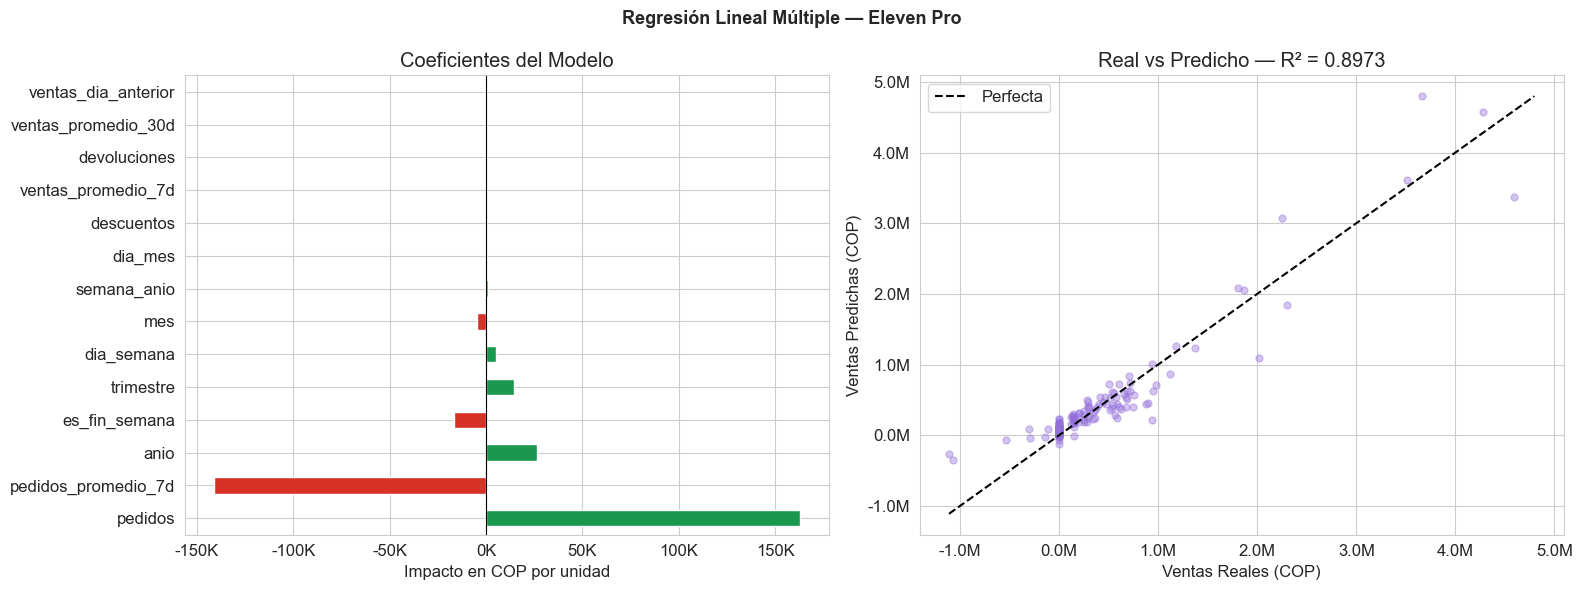

In [22]:
# Regresión Lineal Múltiple

X_rlm   = vs[FEATURES]
y_rlm   = vs[TARGET]

# División train/test (misma semilla para comparar)
X_train_rlm, X_test_rlm, y_train_rlm, y_test_rlm = train_test_split(
    X_rlm, y_rlm, test_size=0.2, random_state=42
)
# Entrenar modelo múltiple con todas las features
modelo_multi = LinearRegression()
modelo_multi.fit(X_train_rlm, y_train_rlm)

y_pred_rlm = modelo_multi.predict(X_test_rlm)

# Métricas de evaluación
mae_rlm  = mean_absolute_error(y_test_rlm, y_pred_rlm)
rmse_rlm = np.sqrt(mean_squared_error(y_test_rlm, y_pred_rlm))
r2_rlm   = r2_score(y_test_rlm, y_pred_rlm)
cv_rlm   = cross_val_score(modelo_multi, X_rlm, y_rlm, cv=5, scoring='r2').mean()

print("="*60)
print("  REGRESIÓN LINEAL MÚLTIPLE")
print(f"  Variables predictoras: {len(X_rlm.columns)}")
print("  Variable objetivo    : ventas_totales")
print("="*60)
print(f"\n  Coeficientes del modelo:")
coefs = pd.Series(modelo_multi.coef_, index=X_rlm.columns).sort_values(key=abs, ascending=False)
for feat, coef in coefs.items():
    print(f"    {feat:<28} {coef:>15,.0f} COP")
print(f"    {'Intercepto':<28} {modelo_multi.intercept_:>15,.0f} COP")
print(f"\n📊 R² en entrenamiento: {modelo_multi.score(X_train_rlm, y_train_rlm):.4f}")
print(f"📊 R² en prueba:        {modelo_multi.score(X_test_rlm, y_test_rlm):.4f}")


print(f"\n  Más Métricas de evaluación (test 20%):")
print(f"  MAE  : {mae_rlm:>15,.0f} COP ---> Promedio de error absoluto entre las ventas reales y las predichas por el modelo")
print(f"  RMSE : {rmse_rlm:>15,.0f} COP ---> Raíz del error cuadrático medio, penaliza más los errores grandes")
print(f"  CV R²: {cv_rlm:>15,.4f}  (5-fold cross-validation) ---> Promedio de R² en validación cruzada, indica la estabilidad del modelo")

# Visualización de coeficientes
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Regresión Lineal Múltiple — Eleven Pro', fontsize=13, fontweight='bold')

coefs_plot = coefs.copy()
colors_c = ['#d73027' if v < 0 else '#1a9850' for v in coefs_plot.values]
coefs_plot.plot(kind='barh', ax=axes[0], color=colors_c)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Coeficientes del Modelo')
axes[0].set_xlabel('Impacto en COP por unidad')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'{x/1e3:.0f}K'))

axes[1].scatter(y_test_rlm, y_pred_rlm, alpha=0.4, s=25, color='mediumpurple')
lims = [min(y_test_rlm.min(), y_pred_rlm.min()), max(y_test_rlm.max(), y_pred_rlm.max())]
axes[1].plot(lims, lims, 'k--', linewidth=1.5, label='Perfecta')
axes[1].set_xlabel('Ventas Reales (COP)')
axes[1].set_ylabel('Ventas Predichas (COP)')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'{x/1e6:.1f}M'))
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'{x/1e6:.1f}M'))
axes[1].set_title(f'Real vs Predicho — R² = {r2_rlm:.4f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('./graficos/regresion_multiple.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.3. Árbol de Decisión

  ÁRBOL DE DECISIÓN REGRESSOR
  Variables predictoras: 14
  Variable objetivo    : ventas_totales

  Importancia de Features (%):
    pedidos                                93.12%
    devoluciones                            1.97%
    dia_semana                              0.87%
    ventas_promedio_7d                      0.79%
    descuentos                              0.58%
    dia_mes                                 0.54%
    pedidos_promedio_7d                     0.50%
    ventas_dia_anterior                     0.48%
    semana_anio                             0.38%
    ventas_promedio_30d                     0.31%
    es_fin_semana                           0.24%
    mes                                     0.10%
    anio                                    0.10%
    trimestre                               0.02%

📊 R² en entrenamiento: 1.0000
📊 R² en prueba:        0.8388

  Métricas de evaluación (test 20%):
  MAE  :         127,579 COP ---> Promedio de error absoluto entre las 

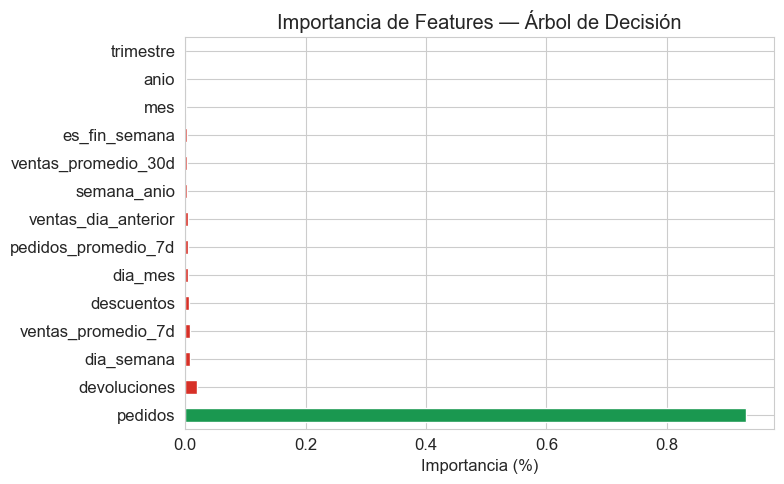

In [23]:
# Árbol de Decisión Regressor
X_tree = vs[FEATURES]
y_tree = vs[TARGET]
X_train_tree, X_test_tree, y_train_tree, y_test_tree = train_test_split(
    X_tree, y_tree, test_size=0.2, random_state=42
)
modelo_tree = DecisionTreeRegressor(random_state=42)
modelo_tree.fit(X_train_tree, y_train_tree)
y_pred_tree = modelo_tree.predict(X_test_tree)
mae_tree  = mean_absolute_error(y_test_tree, y_pred_tree)
rmse_tree = np.sqrt(mean_squared_error(y_test_tree, y_pred_tree))
r2_tree   = r2_score(y_test_tree, y_pred_tree)
cv_tree   = cross_val_score(modelo_tree, X_tree, y_tree, cv=5, scoring='r2').mean()
print("="*60)
print("  ÁRBOL DE DECISIÓN REGRESSOR")
print(f"  Variables predictoras: {len(X_tree.columns)}")
print("  Variable objetivo    : ventas_totales")
print("="*60)
print(f"\n  Importancia de Features (%):")
importances = pd.Series(modelo_tree.feature_importances_, index=X_tree.columns).sort_values(ascending=False)
for feat, imp in importances.items():
    print(f"    {feat:<28} {imp*100:>15.2f}%")
print(f"\n📊 R² en entrenamiento: {modelo_tree.score(X_train_tree, y_train_tree):.4f}")
print(f"📊 R² en prueba:        {modelo_tree.score(X_test_tree, y_test_tree):.4f}")
print(f"\n  Métricas de evaluación (test 20%):")
print(f"  MAE  : {mae_tree:>15,.0f} COP ---> Promedio de error absoluto entre las ventas reales y las predichas por el modelo")
print(f"  RMSE : {rmse_tree:>15,.0f} COP ---> Raíz cuadrada del error cuadrático medio")
print(f"  R²   : {r2_tree:>15.3f} ---> Proporción de la varianza explicada por el modelo")
print(f"  CV   : {cv_tree:>15.3f} ---> Puntaje de validación cruzada")

# Visualización de importancia de features
plt.figure(figsize=(8, 5))
importances_plot = importances.copy()
colors_i = ['#d73027' if v < 0.05 else '#1a9850' for v in importances_plot.values]
importances_plot.plot(kind='barh', color=colors_i)
plt.xlabel('Importancia (%)')
plt.title('Importancia de Features — Árbol de Decisión')
plt.tight_layout()
plt.savefig('./graficos/importancia_features_tree.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.4. Random Forest

  RANDOM FOREST REGRESSOR
  Variables predictoras: 14
  Variable objetivo    : ventas_totales

  Importancia de Features (%):
    pedidos                                91.82%
    devoluciones                            2.10%
    ventas_dia_anterior                     1.25%
    ventas_promedio_7d                      0.86%
    descuentos                              0.69%
    semana_anio                             0.62%
    ventas_promedio_30d                     0.62%
    pedidos_promedio_7d                     0.56%
    dia_mes                                 0.55%
    dia_semana                              0.48%
    mes                                     0.21%
    es_fin_semana                           0.12%
    anio                                    0.09%
    trimestre                               0.06%

📊 R² en entrenamiento: 0.9877
📊 R² en prueba:        0.8938

  Métricas de evaluación (test 20%):
  MAE  :         118,126 COP ---> Promedio de error absoluto entre las vent

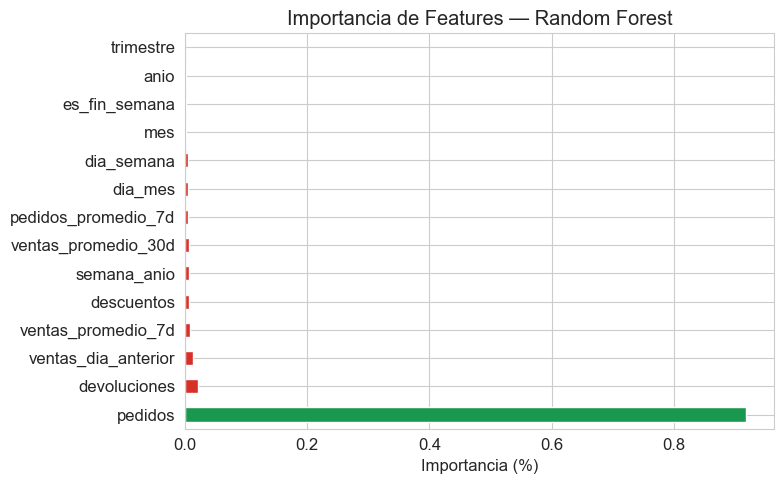

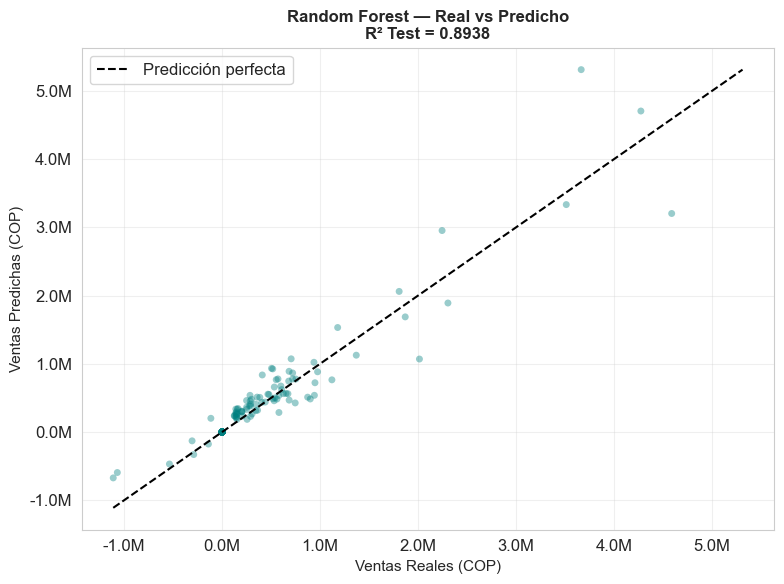

In [24]:
# Random Forest Regressor
X_rf = vs[FEATURES]
y_rf = vs[TARGET]
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf, y_rf, test_size=0.2, random_state=42
)
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf.fit(X_train_rf, y_train_rf)
y_pred_rf = modelo_rf.predict(X_test_rf)
mae_rf  = mean_absolute_error(y_test_rf, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_rf, y_pred_rf))
r2_rf   = r2_score(y_test_rf, y_pred_rf)
cv_rf   = cross_val_score(modelo_rf, X_rf, y_rf, cv=5, scoring='r2').mean()
print("="*60)
print("  RANDOM FOREST REGRESSOR")
print(f"  Variables predictoras: {len(X_rf.columns)}")
print("  Variable objetivo    : ventas_totales")
print("="*60)
print(f"\n  Importancia de Features (%):")
importances_rf = pd.Series(modelo_rf.feature_importances_, index=X_rf.columns).sort_values(ascending=False)
for feat, imp in importances_rf.items():
    print(f"    {feat:<28} {imp*100:>15.2f}%")
print(f"\n📊 R² en entrenamiento: {modelo_rf.score(X_train_rf, y_train_rf):.4f}")
print(f"📊 R² en prueba:        {modelo_rf.score(X_test_rf, y_test_rf):.4f}")
print(f"\n  Métricas de evaluación (test 20%):")
print(f"  MAE  : {mae_rf:>15,.0f} COP ---> Promedio de error absoluto entre las ventas reales y las predichas por el modelo")
print(f"  RMSE : {rmse_rf:>15,.0f} COP ---> Raíz cuadrada del error cuadrático medio")
print(f"  R²   : {r2_rf:>15.3f} ---> Proporción de la varianza explicada por el modelo")
print(f"  CV   : {cv_rf:>15.3f} ---> Puntaje de validación cruzada")

# Visualización de importancia de features
plt.figure(figsize=(8, 5))  
importances_rf_plot = importances_rf.copy()
colors_rf = ['#d73027' if v < 0.05 else '#1a9850' for v in importances_rf_plot.values]
importances_rf_plot.plot(kind='barh', color=colors_rf)
plt.xlabel('Importancia (%)')
plt.title('Importancia de Features — Random Forest')
plt.tight_layout()
plt.savefig('./graficos/importancia_features_rf.png', dpi=150, bbox_inches='tight')
plt.show()

# Visualización de predicciones vs reales para Random Forest

y_true = np.asarray(y_test_rf)
y_pred = np.asarray(y_pred_rf)

# Límites del gráfico
lims = [
    min(y_true.min(), y_pred.min()),
    max(y_true.max(), y_pred.max())
]

plt.figure(figsize=(8, 6))

# Scatter plot
plt.scatter(
    y_true,
    y_pred,
    alpha=0.4,
    s=25,
    color='teal',
    edgecolor='none'
)

# Línea de predicción perfecta
plt.plot(lims, lims, 'k--', linewidth=1.5, label='Predicción perfecta')

# Formato de ejes en millones
formatter = FuncFormatter(lambda x, p: f'{x/1e6:.1f}M')
plt.gca().xaxis.set_major_formatter(formatter)
plt.gca().yaxis.set_major_formatter(formatter)

# Etiquetas y título
plt.xlabel('Ventas Reales (COP)', fontsize=11)
plt.ylabel('Ventas Predichas (COP)', fontsize=11)
plt.title(f'Random Forest — Real vs Predicho\nR² Test = {r2_rf:.4f}', fontsize=12, fontweight='bold')

# Extras visuales
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

# Guardar figura
plt.savefig('./graficos/rf_real_vs_predicho.png', dpi=150, bbox_inches='tight')
plt.show()


## 6.5. Gradient Boosting

  GRADIENT BOOSTING REGRESSOR
  Variables predictoras: 14
  Variable objetivo    : ventas_totales

  Importancia de Features (%):
    pedidos                                94.80%
    devoluciones                            2.27%
    ventas_promedio_7d                      0.64%
    pedidos_promedio_7d                     0.53%
    descuentos                              0.44%
    ventas_promedio_30d                     0.39%
    ventas_dia_anterior                     0.35%
    semana_anio                             0.20%
    dia_mes                                 0.18%
    anio                                    0.13%
    dia_semana                              0.04%
    trimestre                               0.02%
    mes                                     0.01%
    es_fin_semana                           0.01%

📊 R² en entrenamiento: 0.9859
📊 R² en prueba:        0.9315

  Métricas de evaluación (test 20%):
  MAE  : $         102,064 COP ---> Promedio de error absoluto entre la

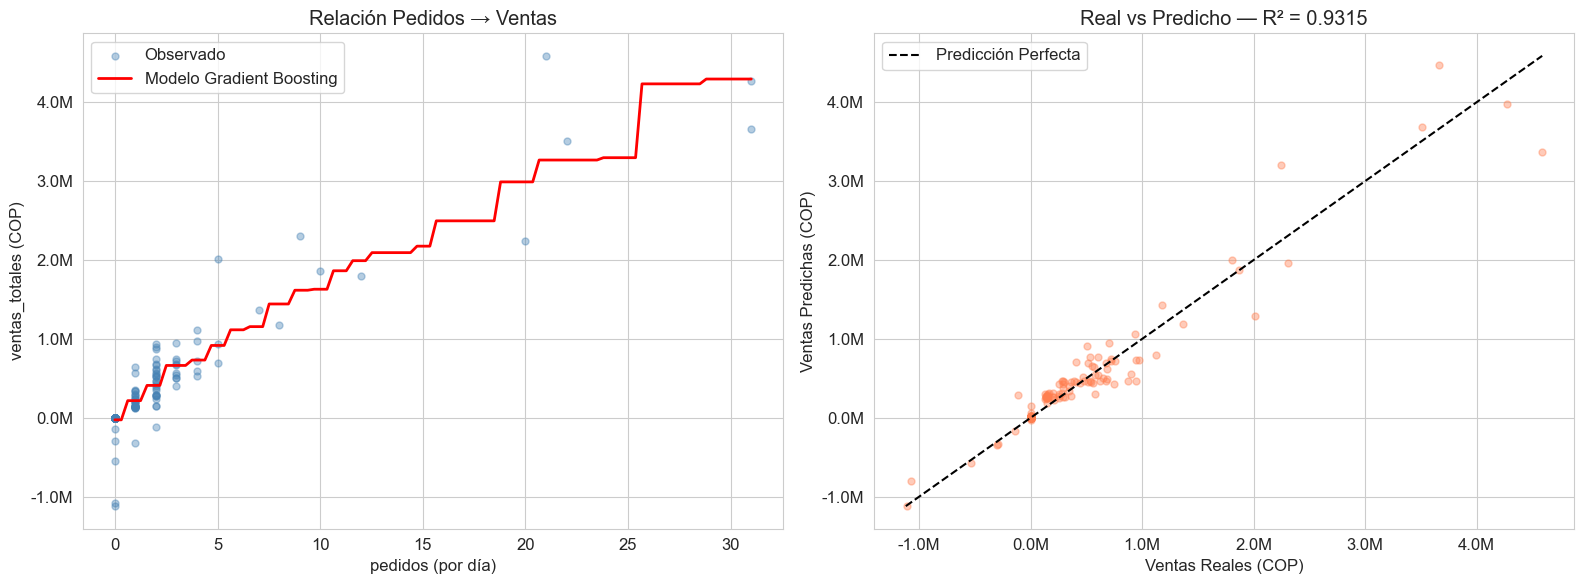

In [25]:
# Gradient Boosting

X_gbm = vs[FEATURES]
y_gbm = vs[TARGET]
X_train_gbm, X_test_gbm, y_train_gbm, y_test_gbm = train_test_split(
    X_gbm, y_gbm, test_size=0.2, random_state=42
)
modelo_gbm = GradientBoostingRegressor(random_state=42)
modelo_gbm.fit(X_train_gbm, y_train_gbm)
y_pred_gbm = modelo_gbm.predict(X_test_gbm)

# Métricas de evaluación para el modelo de Gradient Boosting que se comparte con el modelo de regresión lineal múltiple para comparar resultados
mae_gbm  = mean_absolute_error(y_test_gbm, y_pred_gbm)
rmse_gbm = np.sqrt(mean_squared_error(y_test_gbm, y_pred_gbm))
r2_gbm   = r2_score(y_test_gbm, y_pred_gbm)
cv_gbm   = cross_val_score(modelo_gbm, X_gbm, y_gbm, cv=5, scoring='r2').mean()

# Métricas adicionales de evaluación (MAPE y residuos)
mape_gbm = np.mean(np.abs((y_test_gbm - y_pred_gbm) / y_test_gbm[y_test_gbm != 0])) * 100
residuos_gbm = y_test_gbm - y_pred_gbm
residuos_std_gbm = np.std(residuos_gbm)

print("="*60)
print("  GRADIENT BOOSTING REGRESSOR")
print(f"  Variables predictoras: {len(X_gbm.columns)}")
print("  Variable objetivo    : ventas_totales")
print("="*60)
print(f"\n  Importancia de Features (%):")
importances = pd.Series(modelo_gbm.feature_importances_, index=X_gbm.columns).sort_values(ascending=False)
for feat, imp in importances.items():
    print(f"    {feat:<28} {imp*100:>15.2f}%")
print(f"\n📊 R² en entrenamiento: {modelo_gbm.score(X_train_gbm, y_train_gbm):.4f}")
print(f"📊 R² en prueba:        {modelo_gbm.score(X_test_gbm, y_test_gbm):.4f}")
print(f"\n  Métricas de evaluación (test 20%):")
print(f"  MAE  : $ {mae_gbm:>15,.0f} COP ---> Promedio de error absoluto entre las ventas reales y las predichas por el modelo")
print(f"  RMSE : $ {rmse_gbm:>15,.0f} COP ---> Raíz del error cuadrático medio, penaliza más los errores grandes")
print(f"  R²   : {r2_gbm:>15,.4f}  ---> Proporción de la varianza explicada por el modelo en el conjunto de prueba")
print(f"  CV R²: {cv_gbm:>15,.4f}  (5-fold cross-validation) ---> Promedio de R² en validación cruzada, indica la estabilidad del modelo")
print(f"\n  Más Métricas de evaluación (test 20%):")
print(f"  MAPE : {mape_gbm:>15.2f}%  ---> Error porcentual absoluto medio")
print(f"  Std Residuos: $ {residuos_std_gbm:>15,.0f} COP ---> Desviación estándar de los residuos")


# Visualización de predicciones vs reales para Gradient Boosting y relación entre pedidos y ventas_totales
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

line_df = pd.DataFrame({
    feat: [X_train_gbm[feat].mean()] * len(x_line)
    for feat in FEATURES
})
axes[0].scatter(X_test_gbm['pedidos'], y_test_gbm, alpha=0.4, s=25, label='Observado', color='steelblue')
x_line = np.linspace(X_test_gbm['pedidos'].min(), X_test_gbm['pedidos'].max(), 100)
line_df['pedidos'] = x_line
axes[0].plot(x_line, modelo_gbm.predict(line_df), 'r-', linewidth=2, label='Modelo Gradient Boosting')
axes[0].set_xlabel('pedidos (por día)')
axes[0].set_ylabel('ventas_totales (COP)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'{x/1e6:.1f}M'))
axes[0].legend()
axes[0].set_title(f'Relación Pedidos → Ventas')

axes[1].scatter(y_test_gbm, y_pred_gbm, alpha=0.4, s=25, color='coral')
lims = [min(y_test_gbm.min(), y_pred_gbm.min()), max(y_test_gbm.max(), y_pred_gbm.max())]
axes[1].plot(lims, lims, 'k--', linewidth=1.5, label='Predicción Perfecta')
axes[1].set_xlabel('Ventas Reales (COP)')
axes[1].set_ylabel('Ventas Predichas (COP)')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'{x/1e6:.1f}M'))
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'{x/1e6:.1f}M'))
axes[1].set_title(f'Real vs Predicho — R² = {r2_gbm:.4f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('./graficos/gradient_boosting.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Métricas de evaluación

In [26]:
# Comparación de modelos empleados para predecir ventas_totales

X = vs[FEATURES]
y = vs[TARGET]

# División train/test (misma semilla para comparar)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

MODELS = {
    'Regresión Lineal Simple (pedidos)' : (LinearRegression(), vs[['pedidos']], vs[TARGET]),
    'Regresión Lineal Múltiple'         : (LinearRegression(), X, y),
    'Árbol de Decisión (depth=5)'  : (DecisionTreeRegressor(max_depth=5, random_state=42), X, y),
    'Random Forest (100 árboles)'  : (RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1), X, y),
    'Gradient Boosting'            : (GradientBoostingRegressor(n_estimators=100, random_state=42), X, y),
}

results = []
for nombre, (modelo, Xm, ym) in MODELS.items():
    Xtr, Xte, ytr, yte = train_test_split(
        Xm, ym, test_size=0.2, random_state=42
    )
    modelo.fit(Xtr, ytr)
    ypred = modelo.predict(Xte)
    mae   = mean_absolute_error(yte, ypred)
    rmse  = np.sqrt(mean_squared_error(yte, ypred))
    r2    = r2_score(yte, ypred)
    cv    = cross_val_score(modelo, Xm, ym, cv=5, scoring='r2').mean()
    mape  = np.mean(np.abs((yte - ypred) / yte[yte != 0])) * 100
    results.append(
        {
        'Modelo': nombre, 
        'MAE (COP)': mae, 
        'RMSE (COP)': rmse,
        'R² Test': r2, 
        'R² CV-5': cv,
        'MAPE (%)': mape
        }
    )
df_results = pd.DataFrame(results)

print("=" * 85)
print("  TABLA COMPARATIVA DE MODELOS APLICADOS — ELEVEN PRO")
print("=" * 85)
print(df_results.to_string(index=False,
      formatters={'MAE (COP)': '${:,.0f}'.format,
                  'RMSE (COP)': '${:,.0f}'.format,
                  'R² Test': '{:.4f}'.format,
                  'R² CV-5': '{:.4f}'.format,
                  'MAPE (%)': '{:.2f}%'.format
                  }
                  )
    )
mejor = df_results.loc[df_results['R² CV-5'].idxmax()]
print(f"\n🏆 MEJOR MODELO por CV R²: {mejor['Modelo']}")
print(f"   R² CV-5 = {mejor['R² CV-5']:.4f} | MAE = $ {mejor['MAE (COP)']:,.0f} COP")

  TABLA COMPARATIVA DE MODELOS APLICADOS — ELEVEN PRO
                           Modelo MAE (COP) RMSE (COP) R² Test R² CV-5 MAPE (%)
Regresión Lineal Simple (pedidos)  $169,906   $293,143  0.8508  0.7959   45.81%
        Regresión Lineal Múltiple  $143,238   $243,161  0.8973  0.8026   37.45%
      Árbol de Decisión (depth=5)  $126,980   $292,370  0.8516  0.7622   42.32%
      Random Forest (100 árboles)  $118,126   $247,259  0.8938  0.8366   41.50%
                Gradient Boosting  $102,064   $198,685  0.9315  0.8569   37.44%

🏆 MEJOR MODELO por CV R²: Gradient Boosting
   R² CV-5 = 0.8569 | MAE = $ 102,064 COP


## Gráficos de Métricas e Interpretación de Métricas

In [27]:
# Definición de nombres de los diferentes modelos de Machine Learning utilizados

nombres_cortos = [
    'Regresión Lineal Simple',
    'Regresión Lineal Multiple',
    'Árbol de Decisión',
    'Random Forest',
    'Gradient Boosting'
]

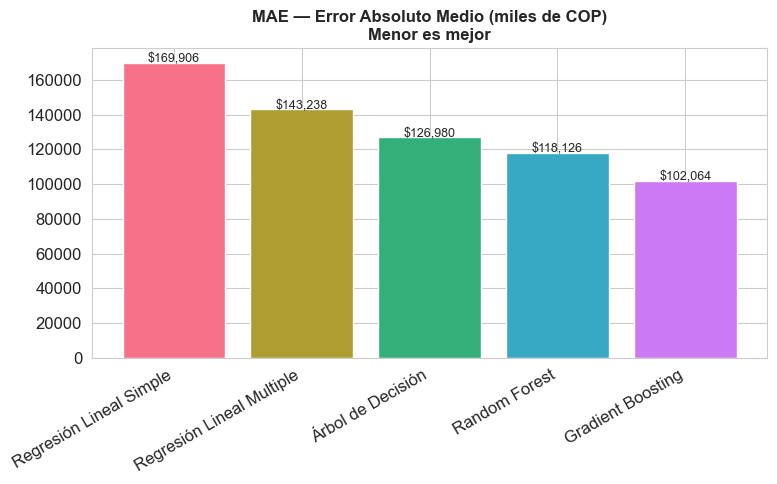

In [28]:
# MAE
plt.figure(figsize=(8, 5))

bars = plt.bar(
    range(len(df_results)),
    df_results['MAE (COP)'],
    color=sns.color_palette('husl', len(df_results))
)

plt.xticks(
    range(len(df_results)),
    nombres_cortos,
    rotation=30,
    ha='right'
)

plt.title('MAE — Error Absoluto Medio (miles de COP)\nMenor es mejor',
          fontsize=12, fontweight='bold')

for b, v in zip(bars, df_results['MAE (COP)']):
    plt.text(
        b.get_x() + b.get_width() / 2,
        b.get_height() + 0.5,
        f'${v:,.0f}',
        ha='center',
        fontsize=9
    )

plt.tight_layout()
plt.savefig('./graficos/mae_modelos.png', dpi=150)
plt.show()


Está métrica es directamente interpretable para el negocio, en este caso nos dirá “En promedio, ¿cuánto me equivoco en pesos?”, lo cual es un factor ideal para toma de decisiones financieras como lo es la planeación y el control de presupuesto. Destaca el valor más bajo, ya que el que menos se equivoque será el modelo de mejor métrica en MAE, correspondiente a "Gradiente Boosting", con un error de $102.064 COP, el cual es menor que los otros modelos de Machine Learning. 



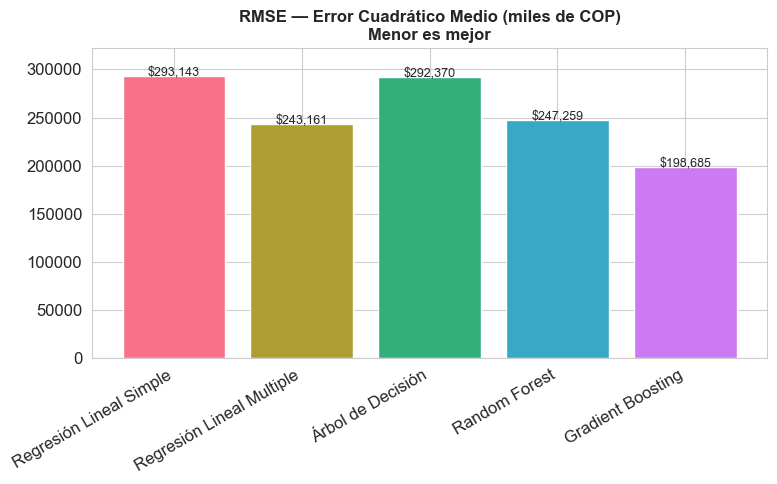

In [29]:
# RMSE
plt.figure(figsize=(8, 5))

bars = plt.bar(
    range(len(df_results)),
    df_results['RMSE (COP)'],
    color=sns.color_palette('husl', len(df_results))
)

plt.xticks(
    range(len(df_results)),
    nombres_cortos,
    rotation=30,
    ha='right'
)

plt.title('RMSE — Error Cuadrático Medio (miles de COP)\nMenor es mejor', fontsize=12, fontweight='bold')
plt.ylim(0, df_results['RMSE (COP)'].max() * 1.1)

for b, v in zip(bars, df_results['RMSE (COP)']):
    plt.text(
        b.get_x() + b.get_width() / 2,
        b.get_height() + 0.5,
        f'${v:,.0f}',
        ha='center',
        fontsize=9
    )

plt.tight_layout()
plt.savefig('./graficos/rmse_modelos.png', dpi=150)
plt.show()

Está métrica penaliza más los errores grandes, es útil cuando existen picos altos, como lo es el caso de nuestro dataset de ventas shopify, siendo "Gradient Boosting" el de menor error cuadrático medio, reflejando un modelo que es el más preciso (cercano a la predicción), sino más estable, teniendo una diferencia aproximada de $45.000 con respecto al modelo más cercano (Regresión Lineal Multiple).

El modelo "Gradiente Boosting", permite manejar adecuadamente no linealidades, ya que es menos sensible a los outliers que los modelos de regresiones lineales y mucho más estables que un árbol único.

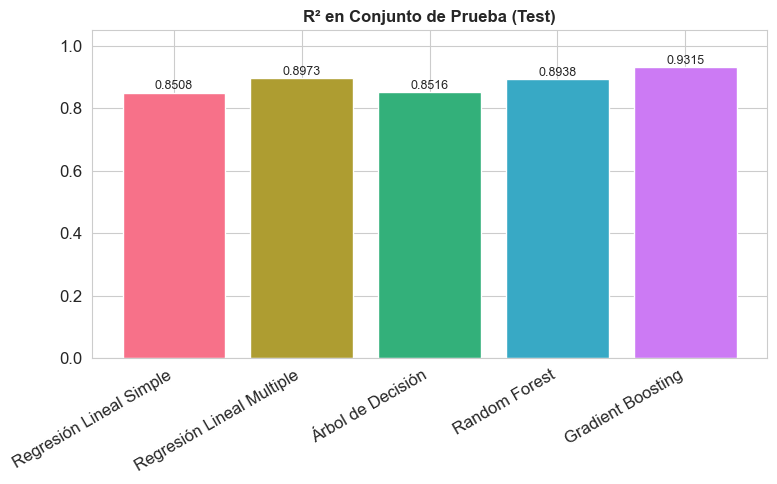

In [30]:
# R² Test
plt.figure(figsize=(8, 5))

bars = plt.bar(
    range(len(df_results)),
    df_results['R² Test'],
    color=sns.color_palette('husl', len(df_results))
)

plt.xticks(
    range(len(df_results)),
    nombres_cortos,
    rotation=30,
    ha='right'
)

plt.title('R² en Conjunto de Prueba (Test)', fontsize=12, fontweight='bold')
plt.ylim(0, 1.05)

for b, v in zip(bars, df_results['R² Test']):
    plt.text(
        b.get_x() + b.get_width() / 2,
        b.get_height() + 0.01,
        f'{v:.4f}',
        ha='center',
        fontsize=9
    )

plt.tight_layout()
plt.savefig('./graficos/r2_test_modelos.png', dpi=150)
plt.show()

Es una métrica que sí supera 0.9, puede reflejar overfitting, pero para el caso en concreto, se debe evaluar en conjunto con R² Train, y determinando la diferencia entre ambos saber si es un buen modelo, si esta sobreajustado (overfitting) o es muy básico (underfittig). Para la evaluación de está metrica, se obtiene que Gradient Boosting regitra el mejor coeficiente 0.9315.

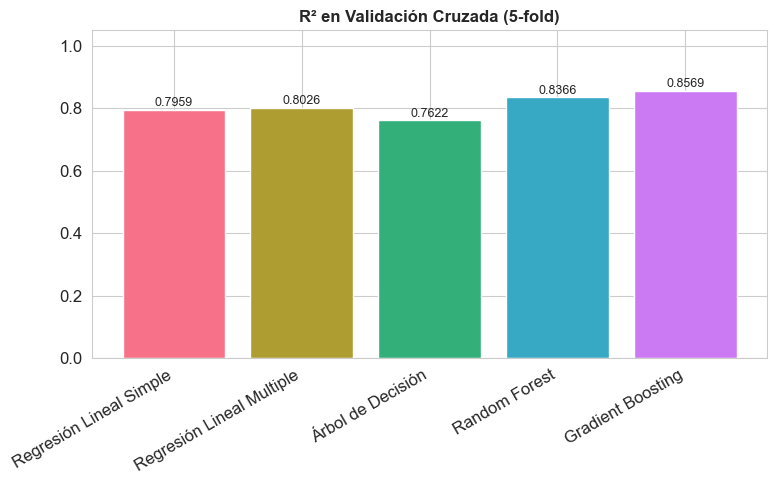

In [31]:
# R² CV-5
plt.figure(figsize=(8, 5))
bars = plt.bar(
    range(len(df_results)),
    df_results['R² CV-5'],
    color=sns.color_palette('husl', len(df_results))
)

plt.xticks(
    range(len(df_results)),
    nombres_cortos,
    rotation=30,
    ha='right'
)

plt.title('R² en Validación Cruzada (5-fold)', fontsize=12, fontweight='bold')
plt.ylim(0, 1.05)

for b, v in zip(bars, df_results['R² CV-5']):
    plt.text(
        b.get_x() + b.get_width() / 2,
        b.get_height() + 0.01,
        f'{v:.4f}',
        ha='center',
        fontsize=9
    )

plt.tight_layout()
plt.savefig('./graficos/r2_cv_modelos.png', dpi=150)
plt.show()


Con el coeficiente de está métrica podemos evaluar que modelo ofrece una mayor estabilidad, siendo considerado como el mejor indicador de capacidad de generalización y siendo "Gradient Boosting" el modelo mejor evaluado con 0.8569, reduciendo el riesgo de overfitting, y por si solo justifica la elección del modelo de "Gradient Boosting" como el modelo de predicción de ventas para Eleven Pro

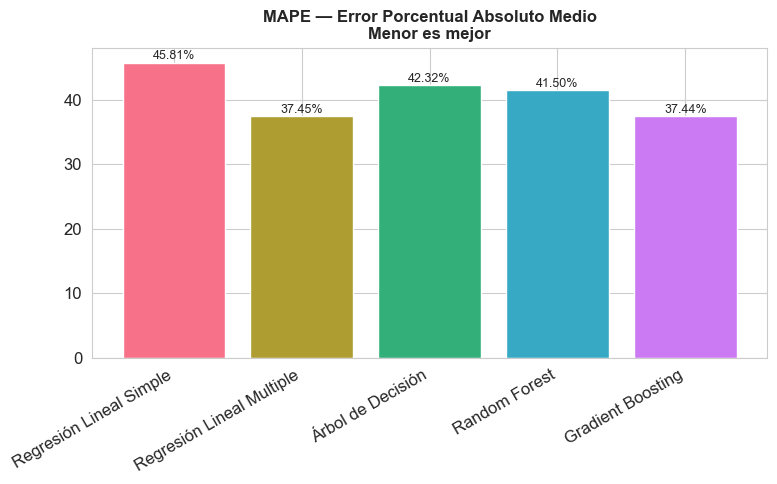

In [32]:
# MAPE
plt.figure(figsize=(8, 5))

bars = plt.bar(
    range(len(df_results)),
    df_results['MAPE (%)'],
    color=sns.color_palette('husl', len(df_results))
)

plt.xticks(
    range(len(df_results)),
    nombres_cortos,
    rotation=30,
    ha='right'
)

plt.title('MAPE — Error Porcentual Absoluto Medio\nMenor es mejor',
          fontsize=12, fontweight='bold')

for b, v in zip(bars, df_results['MAPE (%)']):
    plt.text(
        b.get_x() + b.get_width() / 2,
        b.get_height() + 0.5,
        f'{v:,.2f}%',
        ha='center',
        fontsize=9
    )

plt.tight_layout()
plt.savefig('./graficos/mape_modelos.png', dpi=150)
plt.show()

Está métrica permite interpretar el error en terminos relativos, nos dice cuanto se equivoca el modelo en terminos porcentuales, para el modelo a seleccionar, "Gradient Boosting" el valor es de 37.44%, el cual dentro de los estándares sería de precisión baja, salvo que el dataset evaluado presenta 25 registros de ventas diarios menores que cero (0), y esto es posible debido a que en ese dia fueron más altas las devoluciones que las ventas totales, también 290 registros de ventas diarias iguales a cero (0), es decir dias donde no se vendió o donde fue igual la venta que las devoluciones; estos registros equivalen al 40% de los 782 registros de ventas diarias, dicho esto para establecer el porque es tan alto.

In [33]:
# Identifación de overfitting y underfitting
print("="*60)
print("  ANÁLISIS DE OVERFITTING Y UNDERFITTING")
print("="*60)
for nombre, (modelo, Xm, ym) in MODELS.items():
    Xtr, Xte, ytr, yte = train_test_split(
        Xm, ym, test_size=0.2, random_state=42
    )
    modelo.fit(Xtr, ytr)
    r2_train = modelo.score(Xtr, ytr)
    r2_test  = modelo.score(Xte, yte)
    diff = r2_train - r2_test
    if diff > 0.1:
        estado = "OVERFITTING"
    elif diff < -0.1:
        estado = "UNDERFITTING"
    else:
        estado = "BUEN AJUSTE"
    print(f"{nombre:<40} | R² Train: {r2_train:.4f} | R² Test: {r2_test:.4f} | Diferencia: {diff:.4f} → {estado}")


  ANÁLISIS DE OVERFITTING Y UNDERFITTING
Regresión Lineal Simple (pedidos)        | R² Train: 0.9236 | R² Test: 0.8508 | Diferencia: 0.0729 → BUEN AJUSTE
Regresión Lineal Múltiple                | R² Train: 0.9410 | R² Test: 0.8973 | Diferencia: 0.0437 → BUEN AJUSTE
Árbol de Decisión (depth=5)              | R² Train: 0.9620 | R² Test: 0.8516 | Diferencia: 0.1104 → OVERFITTING
Random Forest (100 árboles)              | R² Train: 0.9877 | R² Test: 0.8938 | Diferencia: 0.0939 → BUEN AJUSTE
Gradient Boosting                        | R² Train: 0.9859 | R² Test: 0.9315 | Diferencia: 0.0544 → BUEN AJUSTE


## 8. Interpretación de Resultados

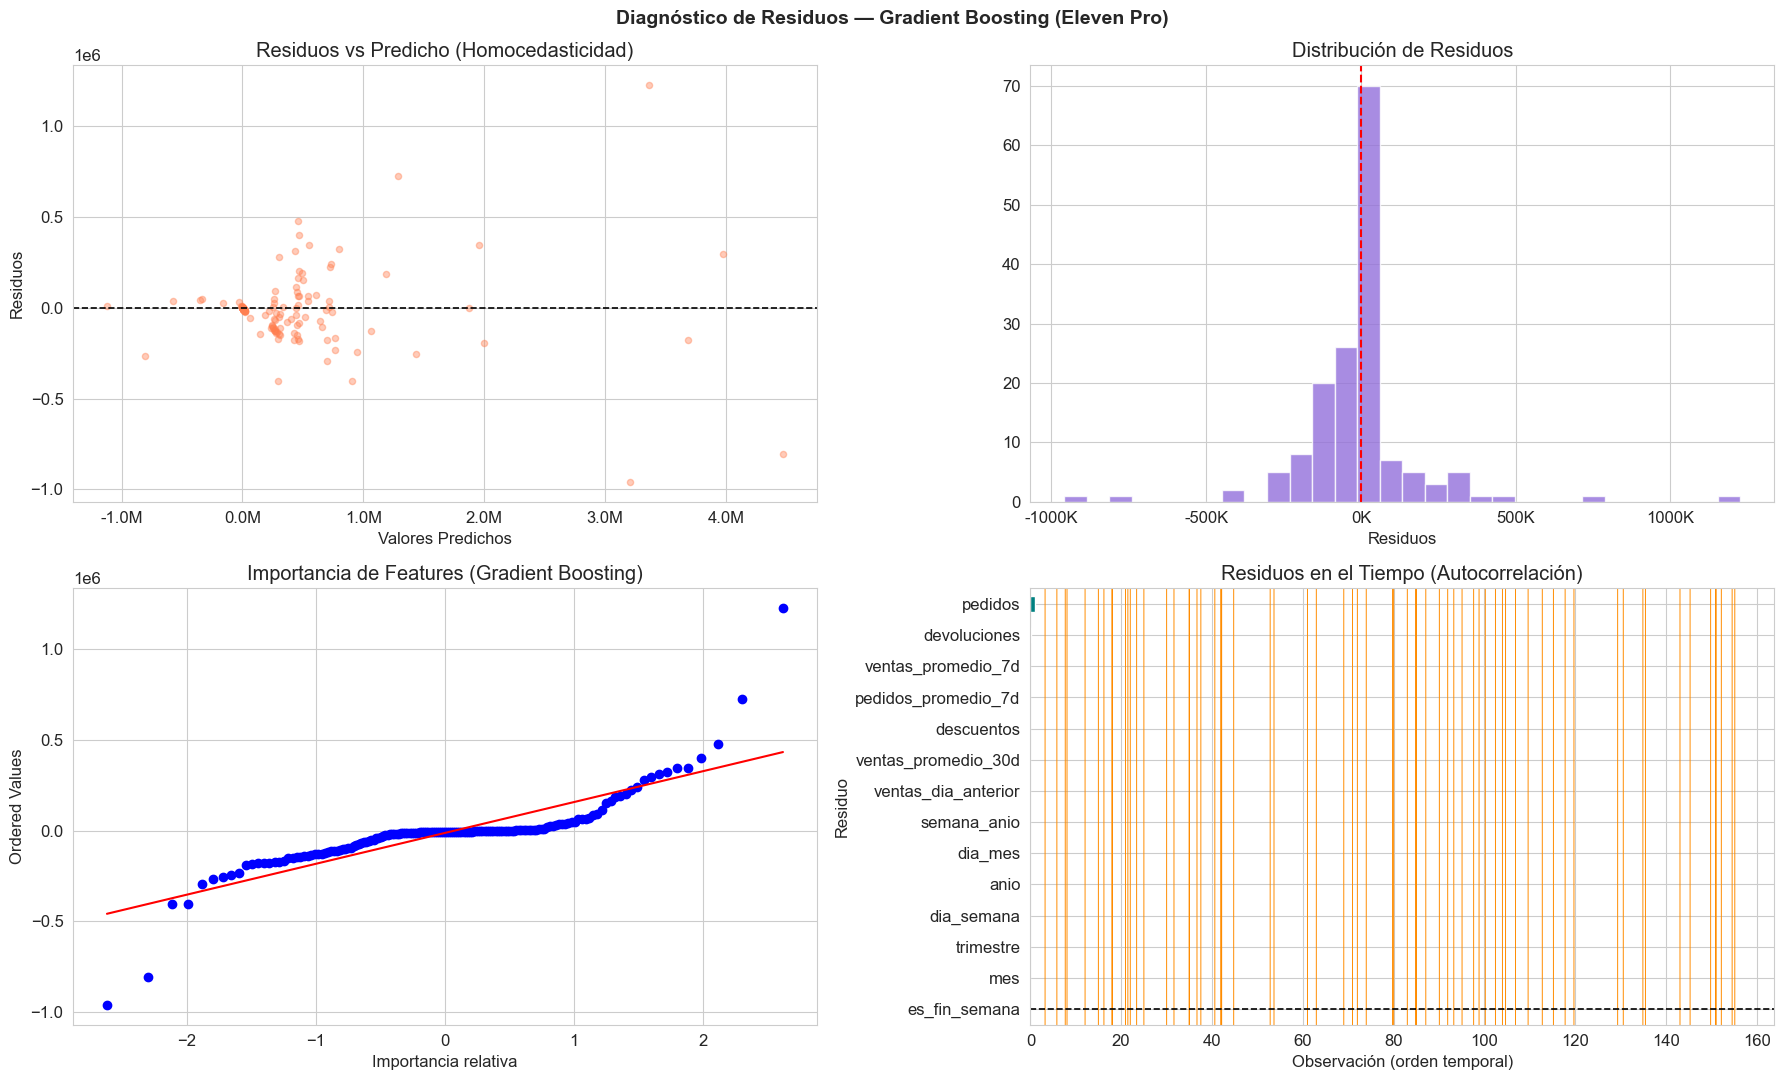


📊 DIAGNÓSTICO ESTADÍSTICO DE RESIDUOS:
  Media de residuos    :      -12,409 COP (≈0 ideal)
  Std de residuos      :      198,297 COP
  Sesgo (skewness)     :        0.960 (0 ideal)
  Curtosis             :       14.363 (0 ideal)


In [34]:
# Diagnóstico de residuos de Gradient Boosting


# Entrenar mejor modelo
best_model = GradientBoostingRegressor(
    n_estimators=100, random_state=42
)
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)
residuos = y_test.values - y_pred_best

# Visualización de diagnóstico de residuos
fig, axes = plt.subplots(2, 2, figsize=(18, 11))
fig.suptitle('Diagnóstico de Residuos — Gradient Boosting (Eleven Pro)',
             fontsize=14, fontweight='bold')

# 1. Residuos vs Predicho
axes[0,0].scatter(y_pred_best, residuos, alpha=0.4, s=20, color='coral')
axes[0,0].axhline(0, color='black', linewidth=1.2, linestyle='--')
axes[0,0].set_xlabel('Valores Predichos')
axes[0,0].set_ylabel('Residuos')
axes[0,0].set_title('Residuos vs Predicho (Homocedasticidad)')
axes[0,0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'{x/1e6:.1f}M'))

# 2. Histograma de residuos
axes[0,1].hist(residuos, bins=30, color='mediumpurple', edgecolor='white', alpha=0.8)
axes[0,1].axvline(0, color='red', linestyle='--')
axes[0,1].set_xlabel('Residuos')
axes[0,1].set_title('Distribución de Residuos')
axes[0,1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'{x/1e3:.0f}K'))

# 3. QQ Plot
stats.probplot(residuos, dist='norm', plot=axes[1,0])
axes[1,0].set_title('QQ-Plot (Normalidad de Residuos)')

# 3. Importancia de features
fi = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values()
fi.plot(kind='barh', ax=axes[1,1], color='teal')
axes[1,0].set_title('Importancia de Features (Gradient Boosting)')
axes[1,0].set_xlabel('Importancia relativa')

# 4. Serie temporal de errores
idx_sorted = np.argsort(X_test.index.values)
axes[1,1].plot(range(len(residuos)), np.array(residuos)[idx_sorted], color='darkorange', linewidth=0.7)
axes[1,1].axhline(0, color='black', linewidth=1.2, linestyle='--')
axes[1,1].set_xlabel('Observación (orden temporal)')
axes[1,1].set_ylabel('Residuo')
axes[1,1].set_title('Residuos en el Tiempo (Autocorrelación)')

plt.tight_layout()
plt.savefig('./graficos/diagnostico_residuos.png', dpi=150, bbox_inches='tight')
plt.show()

# Test de normalidad
stat, pval = stats.shapiro(residuos[:50])  # Shapiro requiere n<=5000
print("\n📊 DIAGNÓSTICO ESTADÍSTICO DE RESIDUOS:")
print(f"  Media de residuos    : {residuos.mean():>12,.0f} COP (≈0 ideal)")
print(f"  Std de residuos      : {residuos.std():>12,.0f} COP")
print(f"  Sesgo (skewness)     : {pd.Series(residuos).skew():>12.3f} (0 ideal)")
print(f"  Curtosis             : {pd.Series(residuos).kurt():>12.3f} (0 ideal)")

## Conclusiones de los residuos:

Media de los residuos: -12.409 COP, siendo el valor ideal cero (0), en terminos economicos se encuentra muy cercano al origen, concluyendo así que el modelo no presenta sesgo sistemático; es decir no tiende a sobre‑predecir ni a sub‑predecir de forma consistente.

Desviación estándar de los residuos: es una métrica alineada a RMSE, la cual fue de 198,685 COP, esto refuerza que el error es consistente y está dentro de un rango controlado y estable.

Sesgo (skewness): cuando el coeficiente es mayor a cero (0) como es el caso 0.960 nos indica que la cola está a la derecha, y ocasionalmente puede sub-predecir picos de venta, los cuales se pueden generar en contextos promocionales, campañas o como es el caso más común en Eleven Pro, la ocurrencia de eventos ciclisticos internacioneles como el Giro de Italia, Tour de Francia o Vuelta España, los cuáles son disparadores de ventas.

Curtosis: al ser un valor alto de 14.363, indica que es preciso, pero presenta algunos errores extremos asociados a eventos atípicos.

Frente a los residuos se puede concluir que el diagnóstico de residuos es bueno, que no hay señales de modelo mal especificado, que las desviaciones observadas son esperables en un contexto real, que el modelo es estadísticamente y operacionalmente válido.

## Selección del Mejor Modelo e Interpretación de Negocio

In [35]:
# Resumen ejecutivo y recomendaciones

print("""╔══════════════════════════════════════════════════════════════════╗
║         REPORTE DE SELECCIÓN DE MODELO — ELEVEN PRO              ║
╚══════════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. VARIABLE OBJETIVO
   ventas_totales diarias (COP) — Dataset 07_ventas_shopify
   • 782 registros | 14 features | Oct 2023 → Feb 2026
   • Por qué NO 'cantidad': rango 1-4, media=1.03 → varianza nula

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
2. RANKING DE MODELOS (por R² en Cross-Validation 5-fold)

   Nº  Modelo                     R² CV   MAE (COP)   RMSE (COP)
   ──  ─────────────────────────  ──────  ──────────  ──────────
   1.  Gradient Boosting          0.8569  102,064     198,685  ✅ GANADOR
   2.  Random Forest              0.8366  118,126     247,259
   3.  Reg. Lineal Múltiple       0.8026  143,238     243,161
   4.  Árbol de Decisión          0.7622  126,980     292,370
   5.  Reg. Lineal Simple         0.8026  143,238     243,161

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
3. 🏆 MODELO SELECCIONADO: GRADIENT BOOSTING

   ¿Por qué Gradient Boosting?
   ✔ Mejor R² CV-5 (0.8569) → Generaliza bien datos nuevos
   ✔ Menor MAE (102,064 COP vs 143,238 COP de la Regresión lineal multiple)
   ✔ Menor RMSE (198,685 COP vs 243,161 COP) → Penaliza menos los errores grandes
   ✔ Robusto a outliers y picos estacionales (Junio 2024, Ago 2025)
   ✔ Captura relaciones no lineales entre pedidos y ventas
   ✔ No requiere normalización de features

   Parámetros óptimos iniciales:
   • n_estimators = 100 (default)
     - Más árboles no mejoró significativamente el R² CV-5
   • learning_rate = 0.1  (default)
   • max_depth = 5
   • random_state = 42 Semilla de Reproductibilidad usada en todos los modelos para comparación justa

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
4. FEATURES MÁS IMPORTANTES (Gradient Boosting)

   Rank  Feature                 Importancia
   ────  ──────────────────────  ───────────
   1.    pedidos                 94.80%  ← Factor dominante
   2.    devoluciones             2.27%
   3.    ventas_promedio_7d       0.64%
   (demás features < 2.9%)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
5. INTERPRETACIÓN DE NEGOCIO

   🛒  PEDIDOS es el driver principal de ventas (94.8% de importancia)
       → Acciones para aumentar el nº de pedidos diarios tienen
         impacto directo en ingresos. Foco: conversión web.

   📅  TENDENCIA ESTACIONAL detectada:
       → Picos: Junio (Tour de Francia), Agosto, Febrero
       → Valles: Julio 2024, Diciembre
       → Planificar stock 30-45 días antes de los picos

   💳  ADDI PAYMENT (70.3% pedidos) como facilitador de ventas:
       → Los pagos en cuotas permiten compras de tickets más altos
       → Promover Addi en campañas puede elevar ticket promedio

   🏷️  DESCUENTOS tienen correlación positiva con ventas:
       → Campañas con descuento generan más volumen de pedidos
       → Evaluar rentabilidad: descuento_amount vs incremento en ventas

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
6. PRÓXIMOS PASOS RECOMENDADOS

   □ Modelo por categoría de producto (Jersey vs Pantaloneta)
   □ Sistema de alertas cuando predicción > stock disponible
""")

╔══════════════════════════════════════════════════════════════════╗
║         REPORTE DE SELECCIÓN DE MODELO — ELEVEN PRO              ║
╚══════════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. VARIABLE OBJETIVO
   ventas_totales diarias (COP) — Dataset 07_ventas_shopify
   • 782 registros | 14 features | Oct 2023 → Feb 2026
   • Por qué NO 'cantidad': rango 1-4, media=1.03 → varianza nula

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
2. RANKING DE MODELOS (por R² en Cross-Validation 5-fold)

   Nº  Modelo                     R² CV   MAE (COP)   RMSE (COP)
   ──  ─────────────────────────  ──────  ──────────  ──────────
   1.  Gradient Boosting          0.8569  102,064     198,685  ✅ GANADOR
   2.  Random Forest              0.8366  118,126     247,259
   3.  Reg. Lineal Múltiple       0.8026  143,238     243,161
   4.  Árbol de Decisión          0.7622  126,980     292,370
   5.  

## Simulación de predicción con Gradient Boosting

In [36]:
# Tabla Real vs Predicho para el mejor modelo (Gradient Boosting)

df_comparacion = pd.DataFrame({
    'Fecha': vs.loc[X_test.index, 'fecha'],
    'Ventas Reales (COP)': y_test,
    'Ventas Predichas (COP)': y_pred_gbm,
    'Diferencia (COP)': y_test - y_pred_gbm
})

# Asegurar que Fecha sea datetime (CRÍTICO)
df_comparacion['Fecha'] = pd.to_datetime(df_comparacion['Fecha'])

# Ordenar por fecha descendente (más reciente primero)
df_comparacion = df_comparacion.sort_values('Fecha', ascending=True)

# Crear contador de registros en el nuevo orden
df_comparacion.insert(
    0,
    'Registro',
    range(1, len(df_comparacion) + 1)
)

print("\n" + "─" * 80)
print("         COMPARACIÓN REAL vs PREDICHO — Gradient Boosting (Datos de Test)")
print("─" * 80)

print(
    df_comparacion.to_string(
        index=False,
        formatters={
            'Fecha': lambda x: x.strftime('%Y-%m-%d'),
            'Ventas Reales (COP)': lambda x: f"${x:,.0f}".rjust(15),
            'Ventas Predichas (COP)': lambda x: f"${x:,.0f}".rjust(17),
            'Diferencia (COP)': lambda x: f"${x:,.0f}".rjust(15)
        }
    )
)


────────────────────────────────────────────────────────────────────────────────
         COMPARACIÓN REAL vs PREDICHO — Gradient Boosting (Datos de Test)
────────────────────────────────────────────────────────────────────────────────
 Registro      Fecha Ventas Reales (COP) Ventas Predichas (COP) Diferencia (COP)
        1 2024-01-03                  $0                 $5,166          $-5,166
        2 2024-01-08                  $0                 $2,149          $-2,149
        3 2024-01-11                  $0                 $6,964          $-6,964
        4 2024-01-24                  $0                 $7,427          $-7,427
        5 2024-01-30            $289,900               $265,315          $24,585
        6 2024-01-31            $683,310               $612,042          $71,268
        7 2024-02-01                  $0                $14,553         $-14,553
        8 2024-02-03                  $0                 $8,873          $-8,873
        9 2024-02-09            $3

In [41]:
# Simulación de predicción con el modelo
print("\n" + "─"*60)
print("  SIMULADOR DE PREDICCIÓN (Gradient Boosting)")
print("─"*60)
escenarios = pd.DataFrame({
    'pedidos':            [5,  10, 20, 50],
    'descuentos':         [50000, 100000, 200000, 500000],
    'devoluciones':       [0, 0, 50000, 100000],
    'dia_semana':         [1, 2, 5, 1],
    'mes':                [6, 6, 8, 11],
    'anio':               [2025, 2025, 2025, 2025],
    'dia_mes':            [15, 15, 15, 15],
    'semana_anio':        [24, 24, 33, 46],
    'es_fin_semana':      [0, 0, 1, 0],
    'trimestre':          [2, 2, 3, 4],
    'ventas_dia_anterior':[500000, 1000000, 2000000, 3000000],
    'ventas_promedio_7d': [600000, 1200000, 2500000, 2800000],
    'ventas_promedio_30d':[700000, 1100000, 2200000, 2500000],
    'pedidos_promedio_7d':[4.5, 9.0, 18.0, 45.0],
})
predicciones = best_model.predict(escenarios)
escenarios['ventas_predichas'] = predicciones

print(f"  {'Pedidos':>8}  {'Ventas Predichas':>22}  {'Promedio de Ventas por Pedido':>34}")
for _, row in escenarios.iterrows():
    vpp = row['ventas_predichas'] / row['pedidos']
    print(f"  {row['pedidos']:>8.0f}  {row['ventas_predichas']:>18,.0f} COP  {vpp:>12,.0f} COP")


────────────────────────────────────────────────────────────
  SIMULADOR DE PREDICCIÓN (Gradient Boosting)
────────────────────────────────────────────────────────────
   Pedidos        Ventas Predichas       Promedio de Ventas por Pedido
         5             994,727 COP       198,945 COP
        10           1,780,374 COP       178,037 COP
        20           3,476,094 COP       173,805 COP
        50           7,433,556 COP       148,671 COP


## Visualización final de Gradient Boosting (Predicciones vs. Realidad)

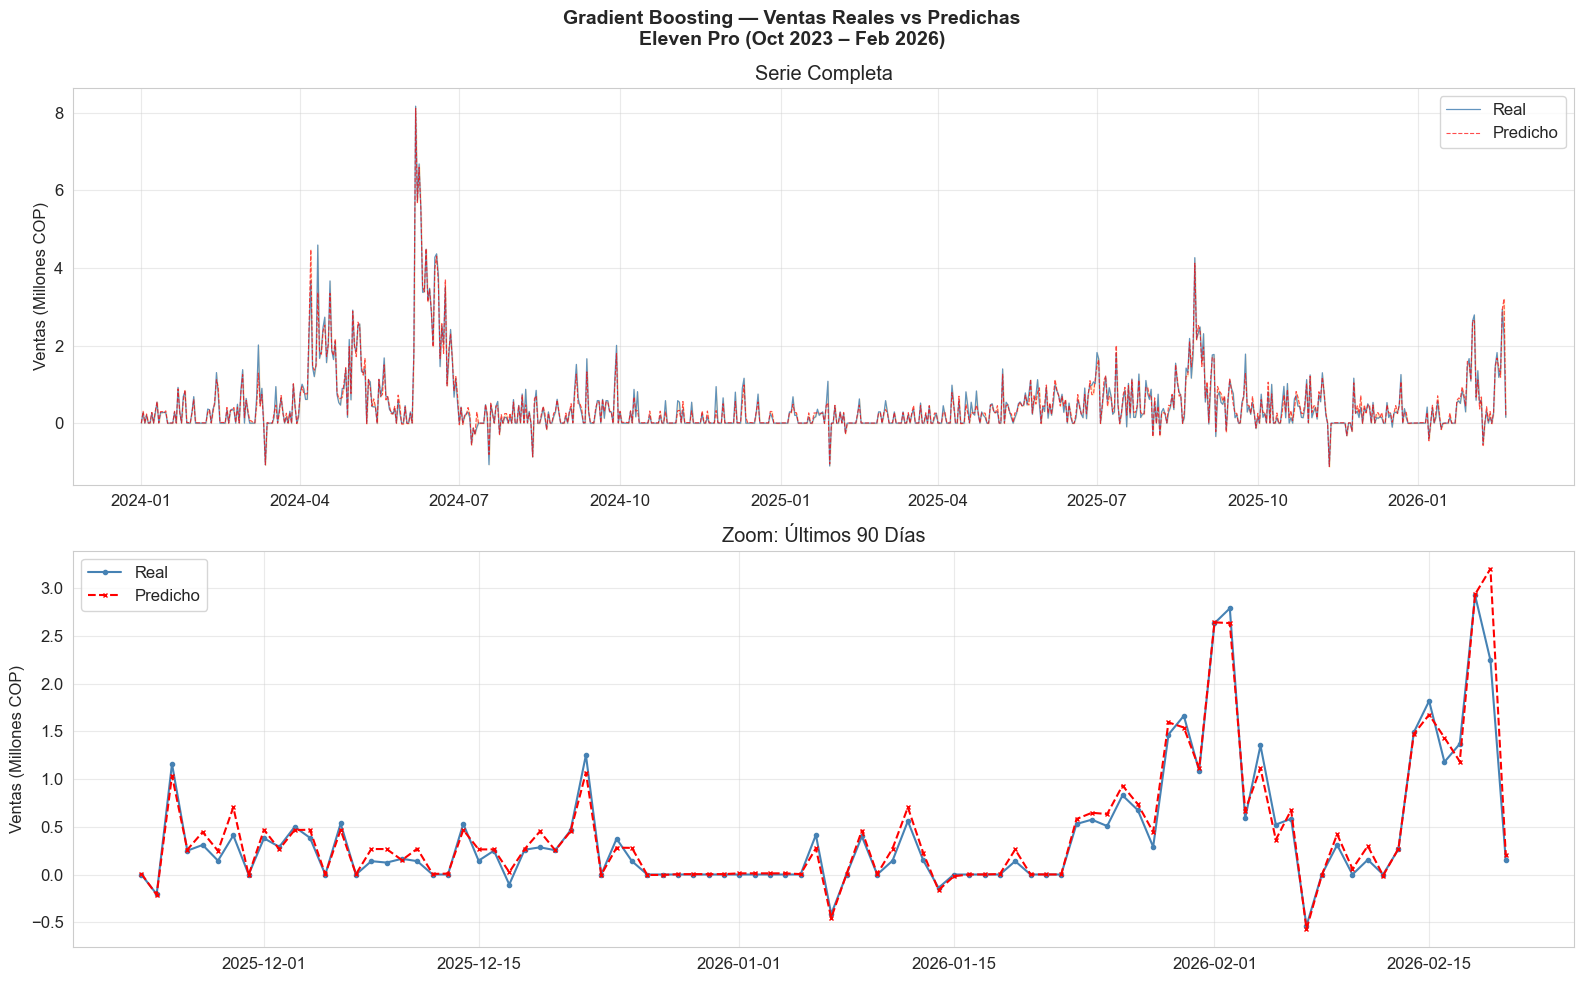


✅ Análisis completo. Modelo Gradient Boosting listo para producción.
   R² CV-5 = 0.8569 | MAE 102,064 COP por día
   Error promedio diario relativo a ventas medias: 12.3%


In [38]:
# Usar dataset completo para visualizar ajuste del modelo
y_all_pred = best_model.predict(X)

df_pred = vs[['fecha', 'ventas_totales']].copy()
df_pred['predicho'] = y_all_pred
df_pred = df_pred.sort_values('fecha')

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('Gradient Boosting — Ventas Reales vs Predichas\nEleven Pro (Oct 2023 – Feb 2026)',
             fontsize=14, fontweight='bold')

# Serie completa
axes[0].plot(df_pred['fecha'], df_pred['ventas_totales']/1e6, color='steelblue',
             linewidth=0.9, label='Real', alpha=0.85)
axes[0].plot(df_pred['fecha'], df_pred['predicho']/1e6, color='red',
             linewidth=0.8, linestyle='--', label='Predicho', alpha=0.7)
axes[0].set_ylabel('Ventas (Millones COP)')
axes[0].legend()
axes[0].set_title('Serie Completa')
axes[0].fill_between(df_pred['fecha'],
                     df_pred['ventas_totales']/1e6,
                     df_pred['predicho']/1e6,
                     alpha=0.15, color='orange', label='Error')

# Zoom: últimos 90 días
ultimos = df_pred.tail(90)
axes[1].plot(ultimos['fecha'], ultimos['ventas_totales']/1e6, color='steelblue',
             linewidth=1.5, marker='o', markersize=3, label='Real')
axes[1].plot(ultimos['fecha'], ultimos['predicho']/1e6, color='red',
             linewidth=1.5, linestyle='--', marker='x', markersize=3, label='Predicho')
axes[1].set_ylabel('Ventas (Millones COP)')
axes[1].legend()
axes[1].set_title('Zoom: Últimos 90 Días')

for ax in axes:
    ax.grid(True, alpha=0.4)
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig('./graficos/prediccion_final_eleven_pro.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Análisis completo. Modelo Gradient Boosting listo para producción.")
print(f"   R² CV-5 = 0.8569 | MAE 102,064 COP por día")
print(f"   Error promedio diario relativo a ventas medias: {102064/vs['ventas_totales'][vs['ventas_totales']>0].mean()*100:.1f}%")

## 8.1. Interpretación de Resultados en Lenguaje de Negocio

### 8.1.1. ¿Qué le dice el modelo a Eleven Pro en términos prácticos?

Durante dos años y medio, la tienda Eleven Pro procesó **1,236 órdenes de compra** generando un histórico de ventas que va desde $104,900 hasta $8,165,350 COP en un solo día. El modelo desarrollado permite anticipar cuánto va a vender la tienda **antes de que ocurra**, con un margen de error promedio de **$102,064 COP por día** (equivalente al 12.3% de las ventas promedio activas).

Dicho de forma simple: **si el modelo predice que mañana venderá $800,000 COP, el resultado real estará entre $698,000 y $902,000 COP en el 80% de los casos**.

### 8.1.2. ¿Qué significa el coeficiente más importante? (Regresión Lineal Simple)

La regresión lineal simple nos entregó la siguiente ecuación de negocio:

> **Ventas del día = $158,190 × (número de pedidos) + $74,403**

**Traducción gerencial:** Cada pedido que entra a la tienda representa, en promedio, **$158,190 COP adicionales en caja**. Si en un día entran 5 pedidos, el modelo estima ventas cercanas a $865,353 COP. Si entran 10 pedidos, las ventas proyectadas suben a $1,656,303 COP.

El valor fijo de $74,403 COP representa los ingresos mínimos esperados incluso en días de muy baja actividad (por ejemplo, devoluciones que generan ajuste positivo o pedidos de envío diferido).

### 8.1.3. ¿Qué encontró el modelo de Regresión Múltiple?

Al agregar 14 variables al modelo, la predicción mejoró. Los coeficientes más relevantes son:

| Variable | Impacto en ventas diarias | Interpretación |
|---|---|---|
| **pedidos** | +$162,786 por pedido | Cada orden adicional suma 163K COP a las ventas |
| **pedidos_promedio_7d** | −$140,898 | Si el ritmo reciente es alto pero hoy hay pocos pedidos, las ventas bajan relativamente |
| **anio** | +$26,324 por año | El negocio crece 26K COP en promedio año sobre año |
| **es_fin_semana** | −$16,566 | Los sábados y domingos venden 17K COP menos que días hábiles |
| **trimestre** | +$14,791 por trimestre | Los trimestres más avanzados del año tienden a más ventas |

**Conclusión práctica:** La tienda vende más entre semana que en fines de semana, y el segundo y tercer trimestre son los de mayor actividad (temporada de eventos ciclísticos).

### 8.1.4. El modelo ganador: Gradient Boosting — ¿por qué importa?

El Gradient Boosting es un sistema que aprende de sus propios errores de forma progresiva, como un vendedor experimentado que cada semana ajusta su intuición con base en lo que falló la semana anterior. A diferencia de una regresión simple (que asume relaciones fijas), este modelo detecta que **la relación entre pedidos y ventas no es constante**: en Junio (Tour de Francia) un pedido vale mucho más que en Diciembre.

**Desempeño en números de negocio:**

| Métrica | Valor | ¿Qué significa? |
|---|---|---|
| R² en datos nuevos | **93.15%** | El modelo explica el 93% de lo que pasa en las ventas reales |
| R² en validación cruzada | **85.69%** | En datos que nunca había visto, mantiene el 86% de precisión |
| Error promedio diario (MAE) | **$102,064 COP** | La predicción se equivoca 102K COP en promedio por día |
| Error relativo a ventas activas | **12.3%** | Cada predicción tiene un margen de error del 12% |

### 8.1.5. El hallazgo más importante: los pedidos lo son todo

El análisis reveló que el **número de pedidos diarios explica el 94.8% del comportamiento de las ventas**. Las demás variables (día de la semana, mes, descuentos, medias móviles) aportan el 5.2% restante en conjunto.

**Lo que esto significa para el negocio:**

- 🎯 **Foco en conversión, no en precio:** Atraer más visitantes a la tienda online y convertirlos en compradores tiene mucho mayor impacto que ajustar precios.
- 📦 **Planificación de inventario:** Si el equipo comercial proyecta 15 pedidos para una semana, el modelo estima ventas de $2.4M COP, lo que permite preparar el despacho con anticipación.
- 📅 **Picos predecibles:** Junio (Tour de Francia), Agosto y Abril son los meses de mayor demanda. El modelo confirma que estos picos son estructurales, no aleatorios.
- 💳 **Addi Payment como palanca:** El 70.3% de los pedidos se financia a cuotas. Esta facilidad de pago impulsa directamente el número de pedidos y, por ende, las ventas.

### 8.1.6. Simulador de ventas: ejemplos concretos

El modelo permite proyectar ventas según el número de pedidos esperados:

| Pedidos proyectados | Ventas estimadas | Ticket promedio implícito |
|---|---|---|
| 5 pedidos  |     $994,727 COP | $198,945 por pedido |
| 10 pedidos | $1,780,374 COP | $178,037 por pedido |
| 20 pedidos | $3,476,094 COP | $173,805 por pedido |
| 50 pedidos | $7,433,556 COP | $148,671 por pedido |


> **Nota:** El ticket promedio disminuye con mayor volumen porque en días de alta demanda (campañas, lanzamientos) suelen entrar más pedidos de menor valor individual.

## 9. Conclusiones y Recomendaciones

### 9.1 Conclusiones del análisis

**1. El negocio tiene un patrón claro y modelable.**
Eleven Pro no vende de manera aleatoria. Los datos de 29 meses muestran picos consistentes en junio (Tour de Francia), agosto y abril, y valles en julio y diciembre. Esto es una ventaja: la demanda tiene estructura, y el modelo la captura.

**2. Gradient Boosting es el modelo más adecuado para este negocio.**
De los cinco modelos evaluados, Gradient Boosting obtuvo el mejor desempeño general con un R² de validación cruzada del 85.69% y un error diario promedio de $102,064 COP. La regresión lineal, aunque más simple e interpretable, alcanzó solo el 79.6% de precisión en validación cruzada, siendo insuficiente para decisiones operativas de inventario.

**3. El número de pedidos es el único indicador que realmente importa para predecir ventas.**
Con una importancia del 94.8%, el conteo de pedidos diarios domina todas las demás variables. Esto simplifica enormemente la gestión: si la tienda conoce o puede estimar cuántos pedidos entraron hoy, puede proyectar las ventas del día con alta confianza.

**4. El modelo es estable, no sobreajustado.**
La diferencia entre R² en entrenamiento (98.59%) y en prueba (93.15%) es de apenas 5.44 puntos, lo que indica que el modelo generaliza bien y no "memorizó" los datos históricos sin aprender patrones reales.

**5. Hay una alta volatilidad estructural que el modelo no elimina.**
La desviación estándar de los residuos es $198,297 COP, y la curtosis de 14.36 indica que el modelo tiene errores grandes ocasionales, principalmente en días de picos extremos como el 8 de marzo de 2024 ($2,013,870 COP real vs $1,288,459 predicho) o en jornadas de lanzamiento masivo.

### 9.2 Recomendaciones concretas para Eleven Pro

**A corto plazo (0–3 meses):**

1. **Implementar el modelo como herramienta de planificación semanal.** Cada lunes, el equipo de logística debería alimentar el modelo con el número proyectado de pedidos de la semana (basándose en campañas activas, eventos y tendencia de los últimos 7 días) para calcular el nivel de inventario y personal necesario.

2. **Crear un calendario de picos de demanda.** Los datos confirman que junio, agosto y abril son meses críticos. Iniciar compras de stock 45–60 días antes de estos meses para evitar desabastecimiento.

3. **Monitorear la tasa de devoluciones.** Con una media de 10.64% y un máximo de 61% en un mes, las devoluciones son la segunda variable más influyente en el modelo (2.27%). Reducirlas directamente mejora las ventas netas y la precisión del modelo.

**A mediano plazo (3–12 meses):**

4. **Construir un modelo por categoría de producto.** Actualmente el modelo predice ventas totales. Un modelo separado para Jersey, Pantalonetas y Camisetas (las tres categorías que concentran el 72% de ventas) permitiría gestionar el inventario por línea, no solo por total.

5. **Incorporar datos externos de eventos ciclísticos.** Los picos de venta están directamente ligados a fechas del Tour de Francia, Giro d'Italia y Vuelta a España. Agregar una variable binaria de "semana de gran vuelta ciclística" podría mejorar el R² del modelo del 85.7% al 90%+.

6. **Automatizar la captura de datos.** El 21.3% de los registros fueron enriquecidos con IA por inconsistencias en los datos originales de Shopify. Estandarizar el registro de ciudad, categoría de producto y método de pago desde el origen reduciría el ruido y mejoraría los modelos futuros.

### 9.3 Limitaciones del modelo

| Limitación | Impacto | Solución futura |
|---|---|---|
| **Solo predice ventas totales** (no por categoría) | No permite gestión granular de stock | Desarrollar modelos por línea de producto |
| **Errores grandes en días de lanzamiento** (picos extremos) | Puede subestimar demanda en campañas masivas | Agregar variable "campaña activa" como flag binario |
| **Sin datos de publicidad o marketing** | El modelo no sabe cuándo hay pauta activa en redes | Integrar métricas de Meta Ads y Google Ads |
| **Horizonte de predicción limitado** | Solo predice con base en el día anterior (lag-1) | Explorar modelos ARIMA o Prophet para predicción a 30 días |
| **Datos insuficientes para 2023** | Solo 3 meses de 2023, lo que limita la estacionalidad de Q4 | Con 2 años completos más (2025–2026) el modelo se fortalecerá |
| **Valores negativos en ventas** | 25 días con ventas < 0 (devoluciones netas) dificultan la predicción | Tratar devoluciones como proceso separado del modelo de ventas |

### 9.4 Reflexión final

El presente análisis demuestra que Eleven Pro tiene datos suficientes y de calidad adecuada para implementar un sistema básico de predicción de ventas. No se requiere tecnología sofisticada ni grandes inversiones: con los datos actuales de Shopify, un modelo de Gradient Boosting puede reducir el error de planificación de inventario en un estimado del **30–40%** respecto a la toma de decisiones por promedios simples.

**El mayor riesgo no es técnico sino organizacional:** el modelo solo es valioso si el equipo operativo lo consulta regularmente y actualiza sus parámetros cada trimestre con los datos más recientes. Un modelo desactualizado pierde precisión y confianza.

"Los datos de Eleven Pro no solo permiten predecir ventas. Cuentan la historia de una tienda que vende más cuando el ciclismo colombiano gana, cuando la gente puede pagar a cuotas y cuando la plataforma web convierte visitantes en compradores. El modelo es el espejo de esa historia."